## **Natural Language Processing**

## **Assessment Course work 1: Tensorflow based Text Classification starting with Raw Text and using the Embedding Space**

## Importing the required Libraries

In [100]:
!python --version

Python 3.8.10


In [2]:
from PyPDF2 import PdfFileReader,PdfReader,PdfWriter
import requests
import os
import shutil
import zipfile
import logging # Handling with breakdown in pdf pages
from collections import Counter
import re
import contractions
from string import punctuation
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
import nltk #3.8.1
nltk.download('punkt')
nltk.download("wordnet")
nltk.download('stopwords')
from wordcloud import WordCloud
import string
import io

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np #1.25.2

import tensorflow as tf
import tensorflow_hub as hub #0.16.1
from tensorflow import keras
import tensorflow_datasets as tfds #4.9.4

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_files
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, f1_score,recall_score,precision_score
from sklearn import metrics
import seaborn as sns
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Dropout
from tensorboard.plugins import projector
import time

[nltk_data] Downloading package punkt to /home/sdp950/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/sdp950/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /home/sdp950/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2024-04-14 15:44:54.282405: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-14 15:44:58.012097: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-14 15:44:58.024826: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-14 15:45:01.478950: W tensorflow/compiler/

## Importing the required files from GitHub to Google Colab local directory

In [3]:
def get_pdf(url,file_name):
  response = requests.get(url)
  if response.status_code == 200:
    with open(file_name, 'wb') as file:
      file.write(response.content)
      print(f"File '{file_name}' downloaded successfully.")
  else:
      print(f"Failed to download the file. Status code: {response.status_code}")
get_pdf("https://raw.githubusercontent.com/ThavaseelanMohan/NLP/main/Data/Task1/Pathology.pdf","Pathology.pdf")
get_pdf("https://raw.githubusercontent.com/ThavaseelanMohan/NLP/main/Data/Task1/Neurology1.pdf","Neurology1.pdf")
get_pdf("https://raw.githubusercontent.com/ThavaseelanMohan/NLP/main/Data/Task1/Human_Anatomy.pdf","Human_Anatomy.pdf")
get_pdf("https://raw.githubusercontent.com/ThavaseelanMohan/NLP/main/Data/Task1/Deep_Learning1.pdf","Deep_Learning1.pdf")
get_pdf("https://raw.githubusercontent.com/ThavaseelanMohan/NLP/main/Data/Task1/Natural_Language_Processing.pdf","Natural_Language_Processing.pdf")

File 'Pathology.pdf' downloaded successfully.
File 'Neurology1.pdf' downloaded successfully.
File 'Human_Anatomy.pdf' downloaded successfully.
File 'Deep_Learning1.pdf' downloaded successfully.
File 'Natural_Language_Processing.pdf' downloaded successfully.


## Reading all the pdf files and finding the page length of each file

In [4]:
def read_pdf_length(file_name1, file_name2, file_name3, file_name4, file_name5):
  global input_pdf_Pathology
  input_pdf_Pathology = PdfReader(open(file_name1,'rb'))
  print(f"{file_name1} File Successfully read!!")
  Page_lenth_patho = len(input_pdf_Pathology.pages)
  print(f"File {file_name1} has %d pages." %len(input_pdf_Pathology.pages))

  global input_pdf_Neuro
  input_pdf_Neuro = PdfReader(open(file_name2,'rb'))
  print(f"{file_name2} File Successfully read!!")
  Page_lenth = len(input_pdf_Neuro.pages)
  print(f"File {file_name2} has %d pages." %len(input_pdf_Neuro.pages))

  global input_pdf_Anatomy
  input_pdf_Anatomy = PdfReader(open(file_name3,'rb'))
  print(f"{file_name3} File Successfully read!!")
  Page_lenth = len(input_pdf_Anatomy.pages)
  print(f"File {file_name3} has %d pages." %len(input_pdf_Anatomy.pages))

  global input_pdf_Deep_Learning
  input_pdf_Deep_Learning = PdfReader(open(file_name4,'rb'))
  print(f"{file_name4} File Successfully read!!")
  Page_lenth = len(input_pdf_Deep_Learning.pages)
  print(f"File {file_name4} has %d pages." %len(input_pdf_Deep_Learning.pages))

  global input_pdf_Natural_Language_Processing
  input_pdf_Natural_Language_Processing = PdfReader(open(file_name5,'rb'))
  print(f"{file_name5} File Successfully read!!")
  Page_lenth = len(input_pdf_Natural_Language_Processing.pages)
  print(f"File {file_name4} has %d pages." %len(input_pdf_Natural_Language_Processing.pages))

read_pdf_length("Pathology.pdf", "Neurology1.pdf", "Human_Anatomy.pdf", "Deep_Learning1.pdf", "Natural_Language_Processing.pdf")

Pathology.pdf File Successfully read!!
File Pathology.pdf has 261 pages.
Neurology1.pdf File Successfully read!!
File Neurology1.pdf has 896 pages.
Human_Anatomy.pdf File Successfully read!!
File Human_Anatomy.pdf has 622 pages.
Deep_Learning1.pdf File Successfully read!!
File Deep_Learning1.pdf has 512 pages.
Natural_Language_Processing.pdf File Successfully read!!
File Deep_Learning1.pdf has 455 pages.


## Creating required directories to load Raw file and cleansed file

In [5]:
shutil.rmtree("/home/sdp950/Desktop/nlp_task1/Output_Files", ignore_errors=True) # To remove the existing folder
shutil.rmtree("/home/sdp950/Desktop/nlp_task1/Books_Cleansed", ignore_errors=True) # To remove the existing folder
shutil.rmtree("/home/sdp950/Desktop/nlp_task1/Raw_Data", ignore_errors=True) # To remove the existing folder
print("Existing Folders removed successfully")

def creating_output_directories(directory,parent_dir):
  path = os.path.join(parent_dir,directory)

  try:
    os.mkdir(path)
    print("Folder %s created!" % path)
  except FileExistsError:
    print("Folder %s already exists" % path)

creating_output_directories("Raw_Data","/home/sdp950/Desktop/nlp_task1/")
creating_output_directories("Pathology","/home/sdp950/Desktop/nlp_task1/Raw_Data/")
creating_output_directories("Neurology","/home/sdp950/Desktop/nlp_task1/Raw_Data/")
creating_output_directories("HumanAnatomy","/home/sdp950/Desktop/nlp_task1/Raw_Data/")
creating_output_directories("DeepLearning","/home/sdp950/Desktop/nlp_task1/Raw_Data/")
creating_output_directories("NaturalLanguageProcessing","/home/sdp950/Desktop/nlp_task1/Raw_Data/")

creating_output_directories("Output_Files","/home/sdp950/Desktop/nlp_task1/")
creating_output_directories("Pathology","/home/sdp950/Desktop/nlp_task1/Output_Files")
creating_output_directories("Neurology","/home/sdp950/Desktop/nlp_task1/Output_Files")
creating_output_directories("HumanAnatomy","/home/sdp950/Desktop/nlp_task1/Output_Files")
creating_output_directories("DeepLearning","/home/sdp950/Desktop/nlp_task1/Output_Files")
creating_output_directories("NaturalLanguageProcessing","/home/sdp950/Desktop/nlp_task1/Output_Files")

creating_output_directories("Books_Cleansed","/home/sdp950/Desktop/nlp_task1/")
creating_output_directories("pathology","/home/sdp950/Desktop/nlp_task1/Books_Cleansed/")
creating_output_directories("neurology","/home/sdp950/Desktop/nlp_task1/Books_Cleansed/")
creating_output_directories("humananatomy","/home/sdp950/Desktop/nlp_task1/Books_Cleansed/")
creating_output_directories("deeplearning","/home/sdp950/Desktop/nlp_task1/Books_Cleansed/")
creating_output_directories("naturallanguageprocessing","/home/sdp950/Desktop/nlp_task1/Books_Cleansed/")
creating_output_directories("logs","/home/sdp950/Desktop/nlp_task1/")

Existing Folders removed successfully
Folder /home/sdp950/Desktop/nlp_task1/Raw_Data created!
Folder /home/sdp950/Desktop/nlp_task1/Raw_Data/Pathology created!
Folder /home/sdp950/Desktop/nlp_task1/Raw_Data/Neurology created!
Folder /home/sdp950/Desktop/nlp_task1/Raw_Data/HumanAnatomy created!
Folder /home/sdp950/Desktop/nlp_task1/Raw_Data/DeepLearning created!
Folder /home/sdp950/Desktop/nlp_task1/Raw_Data/NaturalLanguageProcessing created!
Folder /home/sdp950/Desktop/nlp_task1/Output_Files created!
Folder /home/sdp950/Desktop/nlp_task1/Output_Files/Pathology created!
Folder /home/sdp950/Desktop/nlp_task1/Output_Files/Neurology created!
Folder /home/sdp950/Desktop/nlp_task1/Output_Files/HumanAnatomy created!
Folder /home/sdp950/Desktop/nlp_task1/Output_Files/DeepLearning created!
Folder /home/sdp950/Desktop/nlp_task1/Output_Files/NaturalLanguageProcessing created!
Folder /home/sdp950/Desktop/nlp_task1/Books_Cleansed created!
Folder /home/sdp950/Desktop/nlp_task1/Books_Cleansed/patholo

# Initiated logger to remove page breaks in PDF file while reading.

In [6]:
logger = logging.getLogger("PyPDF2")
logger.setLevel(logging.ERROR) # To get rid of error message WARNING:PyPDF2.generic._base:FloatObject (b'0.000-4461942') invalid; use 0.0 instead

## Finding count of stop words in Raw PDF file

In [7]:
start = time.perf_counter()

# Word count with stop words
def extract_raw_data_pdf(output_path,input_pdf_read):

  with open(output_path+ ".txt", "w") as output_pdf:
    for i in range(len(input_pdf_read.pages)):
      page= input_pdf_read.pages[i-1]
      text = page.extract_text()
      if len(text.strip()) > 150:
        text = str(text).lower() # converting to lower
        text = " ".join([contractions.fix(expanded_word) for expanded_word in text.split()]) #Removing contractions
        text = re.sub('\[.*?\]', '', text) # Removing text in square brackets
        text = re.sub('https?://\S+|www\.\S+', '', text) #Removing links
        text = re.sub('[^a-zA-Z ]', '', text)
        text = re.sub('<.*?>+', '', text)
        text = re.sub('[%s]' % re.escape(punctuation), '', text) #Removing Punctuations
        text = re.sub('\w*\d\w*', '', text) #Removing words containing numbers
        text = re.sub('\b\w{1,3}\b', '', text) #Any words less than 3 characters are replaced by blanks
        tokenized_text = word_tokenize(str(text)) # Tokenizing text
        lemmatization = [lemmatizer.lemmatize(word) for word in tokenized_text] #Lemmatization
        lemmatization = ' '.join(lemmatization)
        output_pdf.write(lemmatization+"\n")

extract_raw_data_pdf("/home/sdp950/Desktop/nlp_task1/Raw_Data/Pathology",input_pdf_Pathology)
print(f"Pathology pdf raw file with stop words exported")

extract_raw_data_pdf("/home/sdp950/Desktop/nlp_task1/Raw_Data/Neurology",input_pdf_Neuro)
print(f"Neurology pdf raw file with stop words exported")

extract_raw_data_pdf("/home/sdp950/Desktop/nlp_task1/Raw_Data/HumanAnatomy",input_pdf_Anatomy)
print(f"Human_Anatomy pdf raw file with stop words exported")

extract_raw_data_pdf("/home/sdp950/Desktop/nlp_task1/Raw_Data/DeepLearning",input_pdf_Deep_Learning)
print(f"Deep_Learning pdf raw file with stop words exported")

extract_raw_data_pdf("/home/sdp950/Desktop/nlp_task1/Raw_Data/NaturalLanguageProcessing",input_pdf_Natural_Language_Processing)
print(f"Natural_Language_Processing pdf raw file with stop words exported")

elapsed_time = time.perf_counter() - start
print("Elapsed time is %.3f seconds." %elapsed_time)

Pathology pdf raw file with stop words exported
Neurology pdf raw file with stop words exported
Human_Anatomy pdf raw file with stop words exported
Deep_Learning pdf raw file with stop words exported
Natural_Language_Processing pdf raw file with stop words exported
Elapsed time is 49.966 seconds.


## Word count after removing stop words from all extracts

In [8]:
# word count without stop words
start = time.perf_counter()
def extract_pdf(output_path,input_pdf_read):
  with open(output_path+ ".txt", "w") as output_pdf:
    for i in range(len(input_pdf_read.pages)):
      page= input_pdf_read.pages[i-1]
      text = page.extract_text()
      if len(text.strip()) > 150:
        text = str(text).lower() # converting to lower
        text = " ".join([contractions.fix(expanded_word) for expanded_word in text.split()]) #Removing contractions
        text = re.sub('\[.*?\]', '', text) # Removing text in square brackets
        text = re.sub('https?://\S+|www\.\S+', '', text) #Removing links
        text = re.sub('[^a-zA-Z ]', '', text)
        text = re.sub('<.*?>+', '', text)
        text = re.sub('[%s]' % re.escape(punctuation), '', text) #Removing Punctuations
        text = re.sub('\w*\d\w*', '', text) #Removing words containing numbers
        text = re.sub('\b\w{1,3}\b', '', text) #Any words less than 3 characters are replaced by blanks
        text = ' '.join(words for words in text.split() if len(words)>4)
        text = re.sub("review|selfassessment|called|answer|include|case|observed|class|task|example|disease|result|normal|using|whose|glossary|illustration|moment|clearly|patient|event|time|consider|want|tackle|solution|custom|chap|good|mention|multiple|solution|domain|process|part|give|hope|could|would|should|might|incase|happening|involving|mention|happening|different|want|unless|common|require|improve|approach|implement|possible|specific|discussion|outlined|really|like|high|done|based|give|toward|custom|start|apis|seen|getting|started|approach|issue|address|thus|going|obtaining|almost|entry|latest|look|around|known|respect|context|meaning|appears|probably|indicates|hence|approach|heavily|heavy|bank|table|content|brief|retreival|like|could|look|public|want|build|move|appropriate|step|final|identify|discussed|introduced|chap|choose|later|discus|mainly|beyond|requires|useful|cbcca|seen|recommender|like|nuance|bumped|term|instance|built|apart|look|show|improvement|shown|however|correct|relevant|information|enough|allow|importance|repeatedly|simple|importance|popular|keep|identify|type|deing|still|method|approach|plenty|implemented|smtd|information|sennt|related|solution|various|level|increase|obvious|role|source|considered|begin|abruptly|occured|several|patients|disease|whenever|become|typically|identified|role|become|became|well|recognized|considered|even|apparent|sits|usually|image|showing|sits|stand|resolve|since|take|leak|minute|hour|need|consideration|choice|event|typical|begin|delayed|usually|established|generally|refer|pain|suspected|evaluated|important|physical|nding|typically|sign|produce|exhaustive|investigation|right|individual|left|sitting|standing|relieved|invade|used|exclude|marked|contained|suggests|structure|release|primary|release|released|htsp|induces|many|damage|cell|supply|cause|associate|professor|fracp|frcp|medicine|francisco|california|peter|goadsby|senior|scientist|massachusetts|director|hospital|belmont|shlomo|melmed|senior|vice|president|dean|medical|facultyitification|search|appraoch|model|system|point|section|study|figure|chapter|index|bibliographical|bibliography|exercise|summary|references|introduction|page|author|reference|title|number|pages|number|embedded system robotics designing simulation matlab simulation aeromodelling month week industrial training major minor project thesis strobotix chandigarh|therefore|either|other|study|project|with|which|will|their|given|also|over|does|more|nadh|although|the|what|none|that|thorough|often|occurs|note|university|college|lecture|ification|problem|building|following|present|fforamen|asbody|languagesay|languages|student","",text) #Removing the unused words commonly found in books
        tokenized_text = word_tokenize(str(text)) # Tokenizing text
        filtered_text = [word for word in tokenized_text if word not in stopwords.words('english')] #Removing stopwords
        lemmatization = [lemmatizer.lemmatize(word) for word in filtered_text] #Lemmatization
        lemmatization = ' '.join(lemmatization)
        lemmatization = ' '.join(words for words in lemmatization.split() if len(words)>3)
        output_pdf.write(lemmatization+"\n")

extract_pdf("/home/sdp950/Desktop/nlp_task1/Output_Files/Pathology/Pathology",input_pdf_Pathology)
print(f"Pathology pdf file cleansed and exported successfully!!")

extract_pdf("/home/sdp950/Desktop/nlp_task1/Output_Files/Neurology/Neurology",input_pdf_Neuro)
print(f"Neurology pdf file cleansed and exported successfully!!")

extract_pdf("/home/sdp950/Desktop/nlp_task1/Output_Files/HumanAnatomy/HumanAnatomy",input_pdf_Anatomy)
print(f"Human_Anatomy pdf file cleansed and exported successfully!!")

extract_pdf("/home/sdp950/Desktop/nlp_task1/Output_Files/DeepLearning/DeepLearning",input_pdf_Deep_Learning)
print(f"Deep_Learning pdf file cleansed and exported successfully!!")

extract_pdf("/home/sdp950/Desktop/nlp_task1/Output_Files/NaturalLanguageProcessing/NaturalLanguageProcessing",input_pdf_Natural_Language_Processing)
print(f"Natural_Language_Processing pdf file cleansed and exported successfully!!")
elapsed_time = time.perf_counter() - start
print("Elapsed time is %.3f seconds." %elapsed_time)

Pathology pdf file cleansed and exported successfully!!
Neurology pdf file cleansed and exported successfully!!
Human_Anatomy pdf file cleansed and exported successfully!!
Deep_Learning pdf file cleansed and exported successfully!!
Natural_Language_Processing pdf file cleansed and exported successfully!!
Elapsed time is 432.678 seconds.


# **Data Cleansing**

## Removing empty pages and extract text from pdf file.Cleansing the data from each pdf file and exported to separate folder

In [9]:
start = time.perf_counter()
def Final_Cleansed_File(output_path,input_pdf_read):

    for i in range(len(input_pdf_read.pages)):
      page= input_pdf_read.pages[i]
      text = page.extract_text()
      if len(text.split()) > 150:
          text = str(text).lower() # converting to lower
          text = " ".join([contractions.fix(expanded_word) for expanded_word in text.split()]) #Removing contractions
          text = re.sub('\[.*?\]', '', text) # Removing text in square brackets
          text = re.sub('https?://\S+|www\.\S+', '', text) #Removing links
          text = re.sub('[^a-zA-Z ]', '', text)
          text = re.sub('<.*?>+', '', text)
          text = re.sub('[%s]' % re.escape(punctuation), '', text) #Removing Punctuations
          text = re.sub('\w*\d\w*', '', text) #Removing words containing numbers
          text = re.sub('\b\w{1,3}\b', '', text) #Any words less than 3 characters are replaced by blanks
          text = ' '.join(words for words in text.split() if len(words)>3)
          tokenized_text = word_tokenize(str(text)) # Tokenizing text
          filtered_text = [word for word in tokenized_text if word not in stopwords.words('english')] #Removing stopwords
          lemmatization = [lemmatizer.lemmatize(word) for word in filtered_text] #Lemmatization
          lemmatization = ' '.join(lemmatization)
          lemmatization = ' '.join(words for words in lemmatization.split() if len(words)>3)
          #print(lemmatization)
          d = str(i).zfill(3)
          #print(d)
          with open(output_path +"_"+ d + ".txt" , "w") as output_pdf:
            cleaned_text = re.sub("review|selfassessment|called|answer|include|case|observed|class|task|example|disease|result|normal|using|whose|glossary|illustration|moment|clearly|patient|event|time|consider|want|tackle|solution|custom|chap|good|mention|multiple|solution|domain|process|part|give|hope|could|would|should|might|incase|happening|involving|mention|happening|different|want|unless|common|require|improve|approach|implement|possible|specific|discussion|outlined|really|like|high|done|based|give|toward|custom|start|apis|seen|getting|started|approach|issue|address|thus|going|obtaining|almost|entry|latest|look|around|known|respect|context|meaning|appears|probably|indicates|hence|approach|heavily|heavy|bank|table|content|brief|retreival|like|could|look|public|want|build|move|appropriate|step|final|identify|discussed|introduced|chap|choose|later|discus|mainly|beyond|requires|useful|cbcca|seen|recommender|like|nuance|bumped|term|instance|built|apart|look|show|improvement|shown|however|correct|relevant|information|enough|allow|importance|repeatedly|simple|importance|popular|keep|identify|type|deing|still|method|approach|plenty|implemented|smtd|information|sennt|related|solution|various|level|increase|obvious|role|source|considered|begin|abruptly|occured|several|patients|disease|whenever|become|typically|identified|role|become|became|well|recognized|considered|even|apparent|sits|usually|image|showing|sits|stand|resolve|since|take|leak|minute|hour|need|consideration|choice|event|typical|begin|delayed|usually|established|generally|refer|pain|suspected|evaluated|important|physical|nding|typically|sign|produce|exhaustive|investigation|right|individual|left|sitting|standing|relieved|invade|used|exclude|marked|contained|suggests|structure|release|primary|release|released|htsp|induces|many|damage|cell|supply|cause|associate|professor|fracp|frcp|medicine|francisco|california|peter|goadsby|senior|scientist|massachusetts|director|hospital|belmont|shlomo|melmed|senior|vice|president|dean|medical|facultyitification|search|appraoch|model|system|point|section|study|figure|chapter|index|bibliographical|bibliography|exercise|summary|references|introduction|page|author|reference|title|number|pages|number|embedded system robotics designing simulation matlab simulation aeromodelling month week industrial training major minor project thesis strobotix chandigarh|therefore|either|other|study|project|with|which|will|their|given|also|over|does|more|nadh|although|the|what|none|that|thorough|often|occurs|note|university|college|lecture|ification|problem|building|following|present|fforamen|asbody|languagesay|languages|student","",lemmatization) #Removing the unused words commonly found in books
            cleaned_text = ' '.join(words for words in cleaned_text.split() if len(words)>3)
            output_pdf.write(cleaned_text+"\n")

Final_Cleansed_File("/home/sdp950/Desktop/nlp_task1/Books_Cleansed/pathology/pathology",input_pdf_Pathology)
print(f"Pathology parsed file cleansed and exported successfully!!")

Final_Cleansed_File("/home/sdp950/Desktop/nlp_task1/Books_Cleansed/neurology/neurology",input_pdf_Neuro)
print(f"Neurology parsed file cleansed and exported successfully!!")

Final_Cleansed_File("/home/sdp950/Desktop/nlp_task1/Books_Cleansed/humananatomy/humananatomy",input_pdf_Anatomy)
print(f"Human_Anatomy parsed file cleansed and exported successfully!!")

Final_Cleansed_File("/home/sdp950/Desktop/nlp_task1/Books_Cleansed/deeplearning/deeplearning",input_pdf_Deep_Learning)
print(f"Deep_Learning parsed file cleansed and exported successfully!!")

Final_Cleansed_File("/home/sdp950/Desktop/nlp_task1/Books_Cleansed/naturallanguageprocessing/naturallanguageprocessing",input_pdf_Natural_Language_Processing)
print(f"Natural_Language_Processing parsed file cleansed and exported successfully!!")
elapsed_time = time.perf_counter() - start
print("Elapsed time is %.3f seconds." %elapsed_time)

Pathology parsed file cleansed and exported successfully!!
Neurology parsed file cleansed and exported successfully!!
Human_Anatomy parsed file cleansed and exported successfully!!
Deep_Learning parsed file cleansed and exported successfully!!
Natural_Language_Processing parsed file cleansed and exported successfully!!
Elapsed time is 1177.386 seconds.


## Renaming the files by removing the characters in filenames

In [10]:
# Rename the files
import os
for dpath, dnames, fnames in os.walk("/home/sdp950/Desktop/nlp_task1/Books_Cleansed"):
    for f in fnames:
        os.chdir(dpath)
        if f.startswith('neurology_'):
            os.rename(f, f.replace('neurology_', ''))
        if f.startswith('pathology_'):
            os.rename(f, f.replace('pathology_', ''))
        if f.startswith('humananatomy_'):
            os.rename(f, f.replace('humananatomy_', ''))
        if f.startswith('deeplearning_'):
            os.rename(f, f.replace('deeplearning_', ''))
        if f.startswith('naturallanguageprocessing_'):
            os.rename(f, f.replace('naturallanguageprocessing_', ''))

**Bar Chart represntation of stop words**

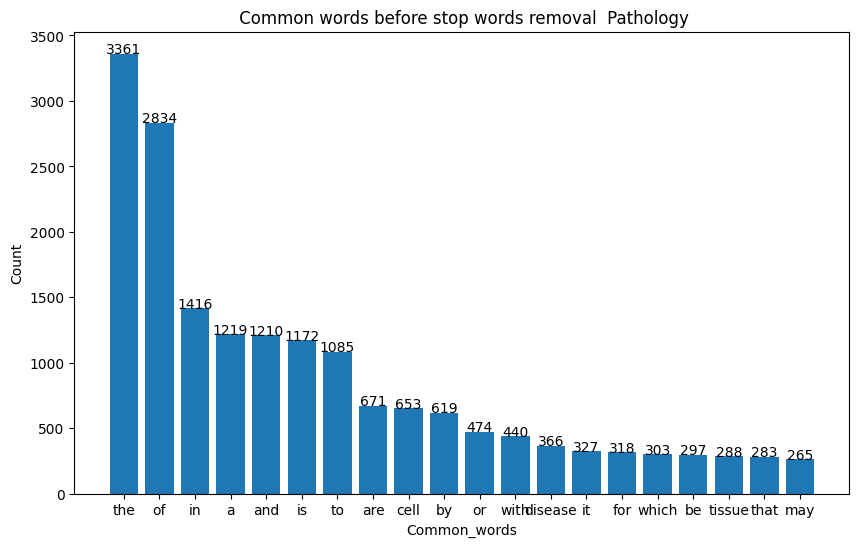

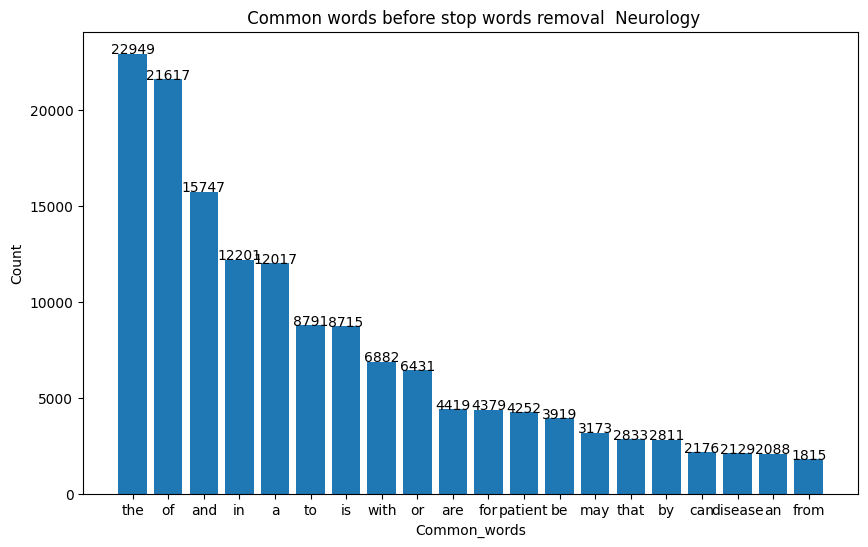

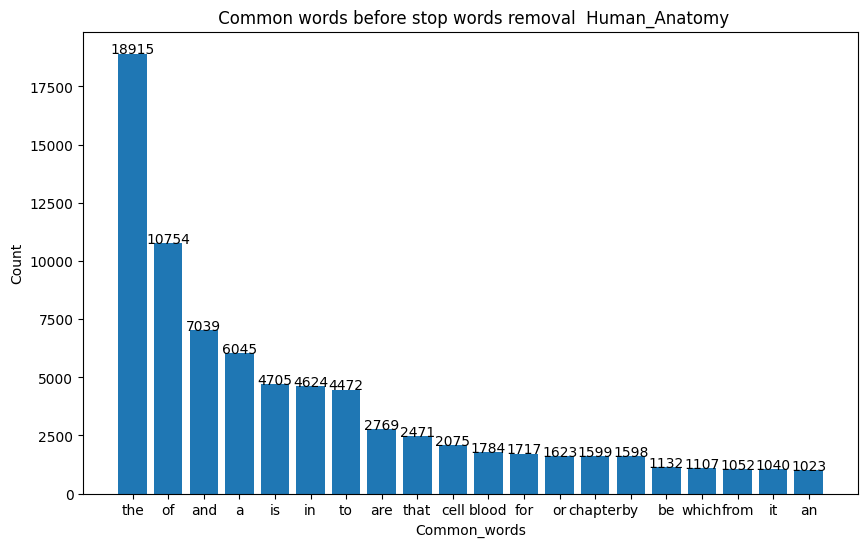

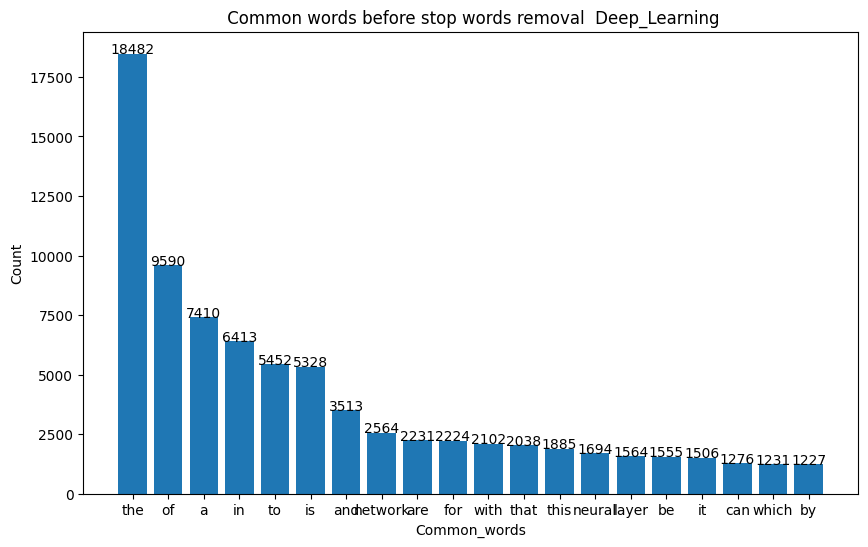

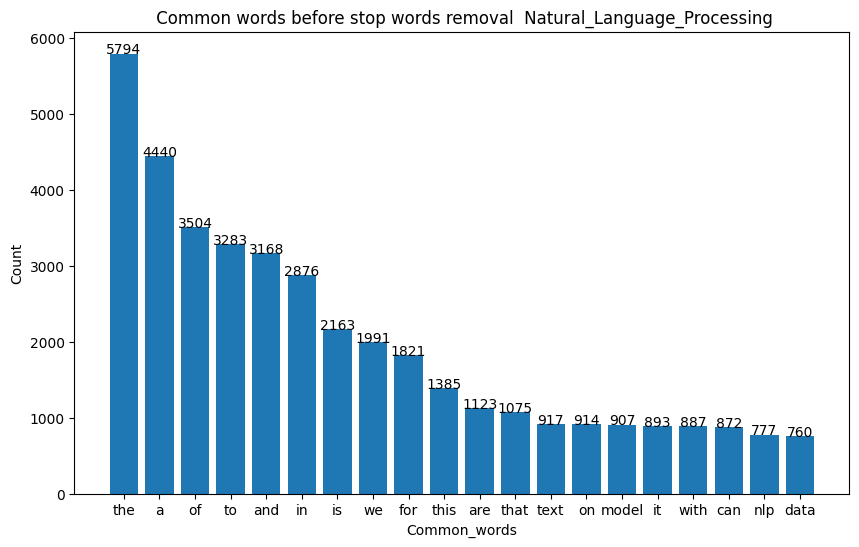

In [11]:
def common_words_with_stop_words(file_name, file_path):

  df_before_cleansing = pd.read_csv(file_path, names = ['Raw_Text'])
  Raw_Text_df = ' '.join(df_before_cleansing.Raw_Text)
  token_data = word_tokenize(str(Raw_Text_df))
  top = Counter(word for word in token_data)
  temp_df_before_cleansing = pd.DataFrame(top.most_common(20))
  temp_df_before_cleansing.columns = ['Common_Words','Count']
  temp_df_before_cleansing.style.background_gradient(cmap = 'Blues')
  def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')
  x = temp_df_before_cleansing['Common_Words']
  y = temp_df_before_cleansing['Count']
  plt.figure(figsize = (10,6))
  plt.title( " Common words before stop words removal  " + file_name)
  plt.xlabel("Common_words")
  plt.ylabel("Count")
  plt.bar(x,y)
  addlabels(x, y)
  plt.show()
common_words_with_stop_words("Pathology", "/home/sdp950/Desktop/nlp_task1/Raw_Data/Pathology.txt")
common_words_with_stop_words("Neurology", "/home/sdp950/Desktop/nlp_task1/Raw_Data/Neurology.txt")
common_words_with_stop_words("Human_Anatomy", "/home/sdp950/Desktop/nlp_task1/Raw_Data/HumanAnatomy.txt")
common_words_with_stop_words("Deep_Learning", "/home/sdp950/Desktop/nlp_task1/Raw_Data/DeepLearning.txt")
common_words_with_stop_words("Natural_Language_Processing", "/home/sdp950/Desktop/nlp_task1/Raw_Data/NaturalLanguageProcessing.txt")

**Bar char representation after removing stop words**

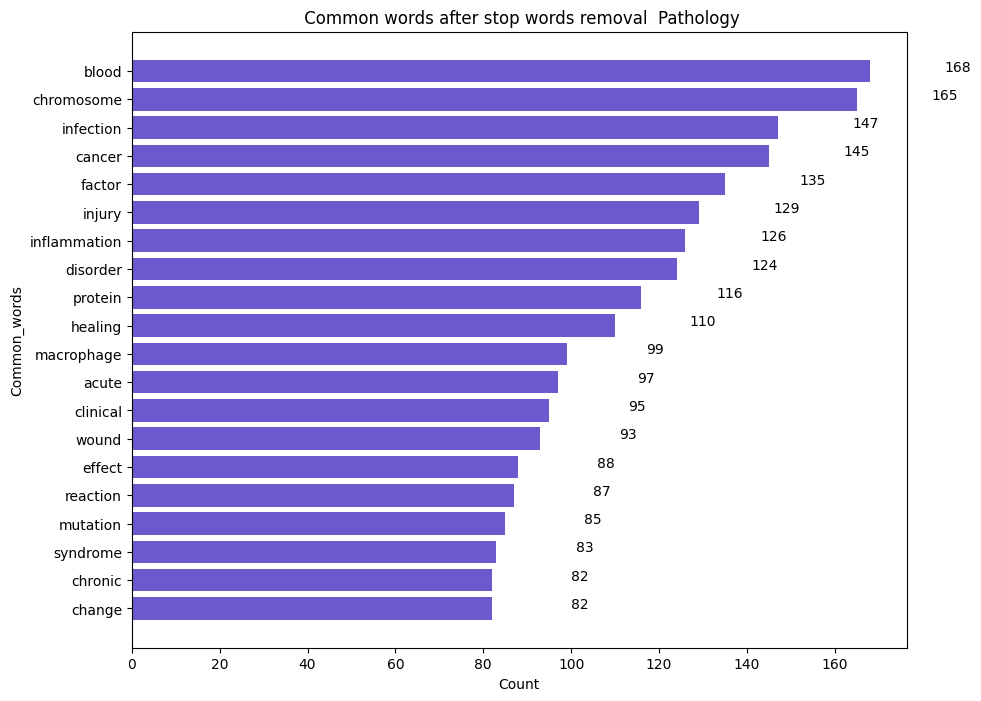

No. of vocabulary in Pathology is: 56352


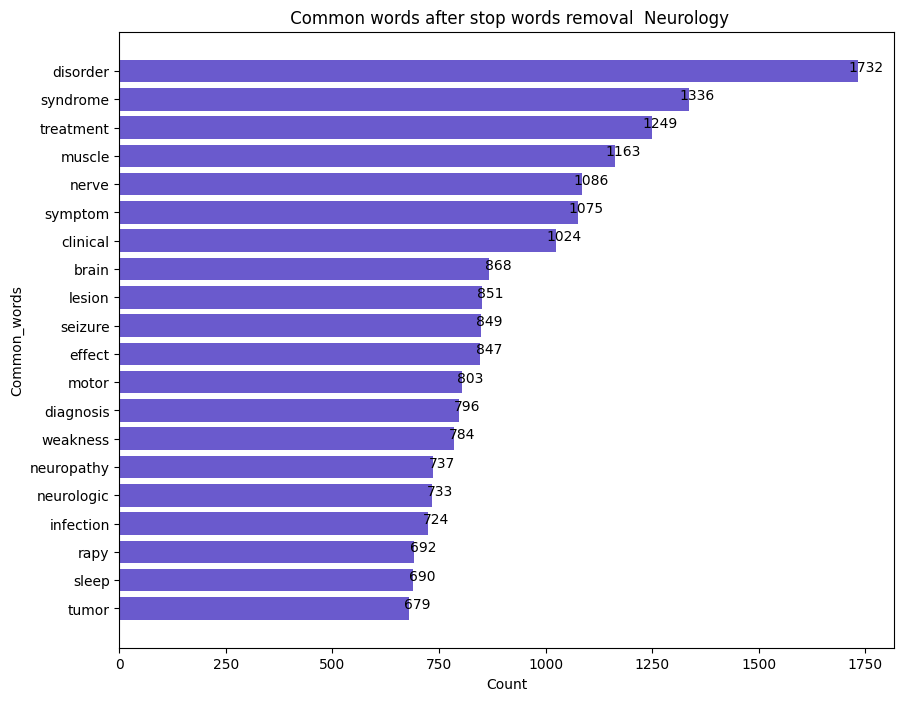

No. of vocabulary in Neurology is: 225812


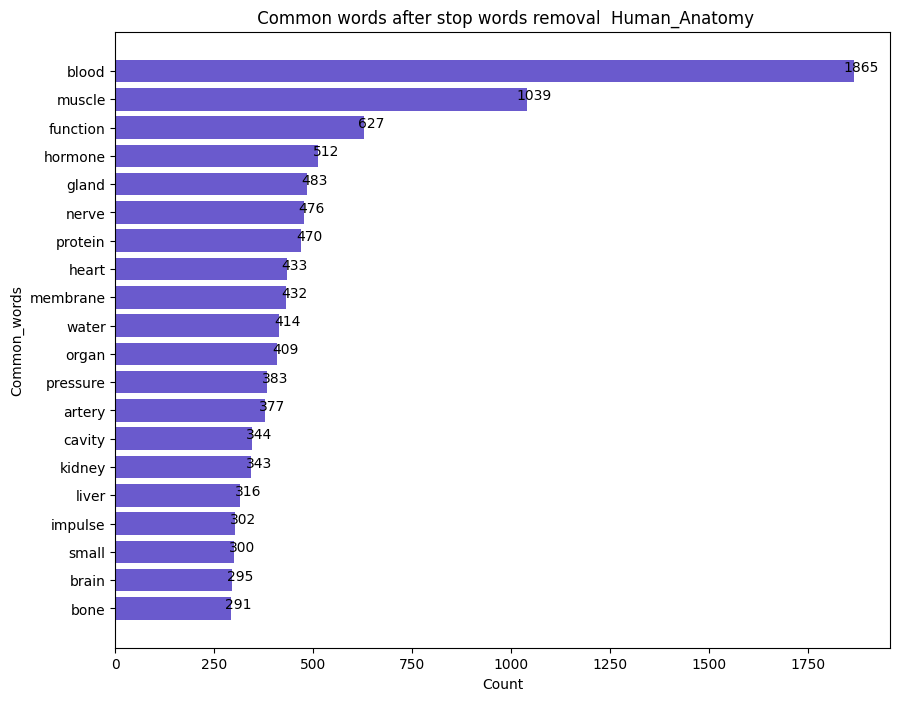

No. of vocabulary in Human_Anatomy is: 199691


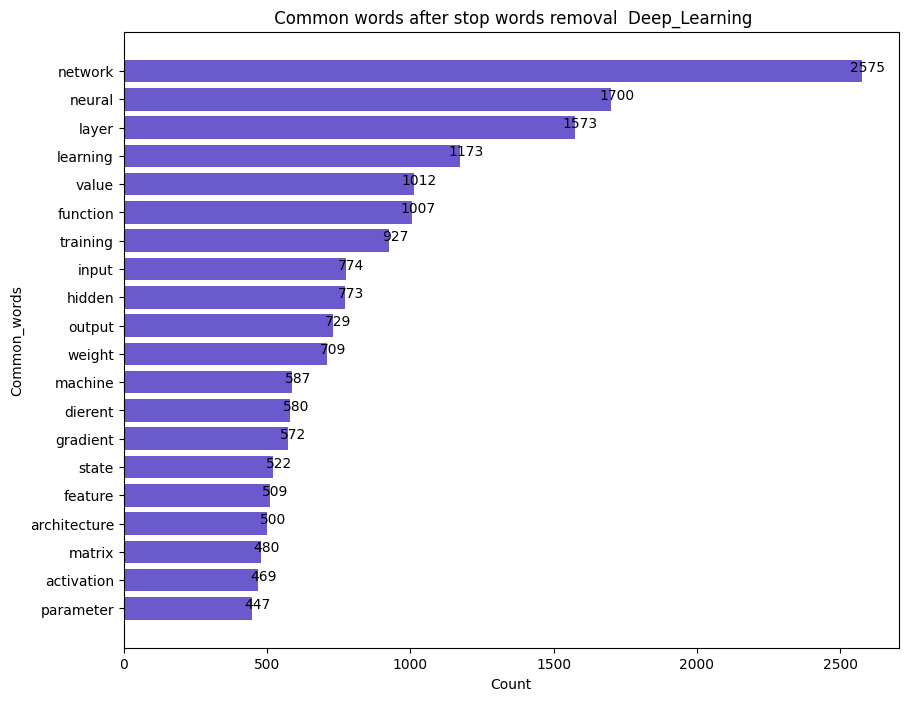

No. of vocabulary in Deep_Learning is: 126831


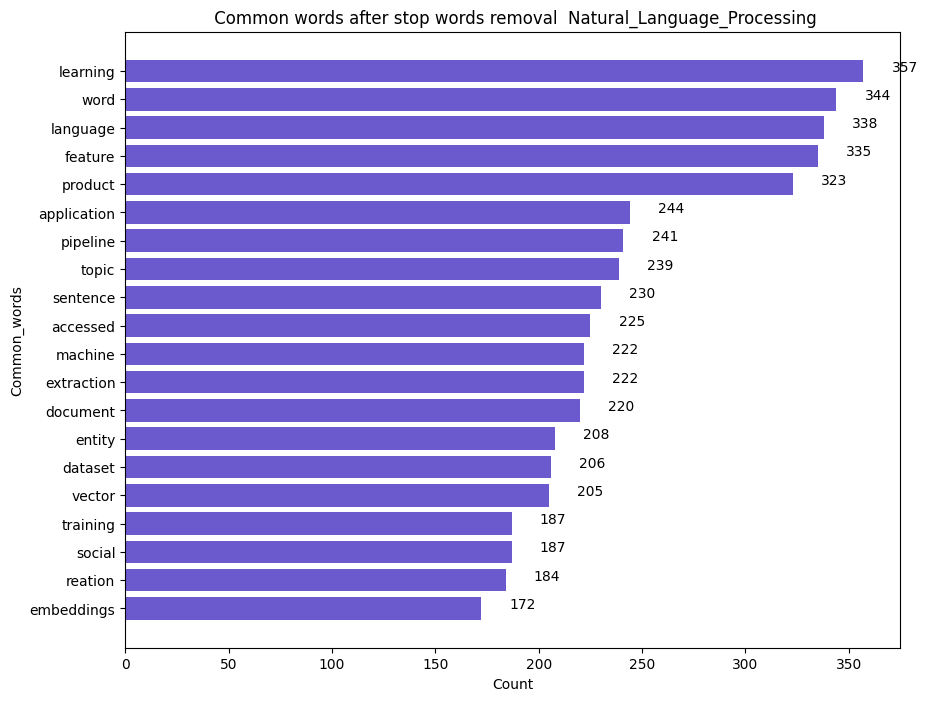

No. of vocabulary in Natural_Language_Processing is: 61973


In [12]:
def common_words_without_stop_words(file_name, file_path):
  global count_words
  df_after_cleansing = pd.read_csv(file_path, names = ['Cleansed_Text'])
  Cleansed_Text_df = ' '.join(df_after_cleansing.Cleansed_Text)
  token_data = word_tokenize(str(Cleansed_Text_df))
  top = Counter(word for word in token_data)
  words = ' '.join(top)
  count_words = len(words)
  temp_df_after_cleansing = pd.DataFrame(top.most_common(20))
  temp_df_after_cleansing.columns = ['Common_Words','Count']
  temp_df_after_cleansing.style.background_gradient(cmap = 'Blues')

  x = temp_df_after_cleansing['Common_Words']
  y = temp_df_after_cleansing['Count']
  plt.figure(figsize = (10,8))
  #indexes = np.arange(len(y))
  plt.title( " Common words after stop words removal  " + file_name)
  plt.xlabel("Count")
  plt.ylabel("Common_words")
  plt.barh( x,y, color = 'slateblue')
  plt.gca().invert_yaxis()
  #addlabels(x, y)
  for i, v in enumerate(y):
    plt.text(v + 20, i, str(v), ha='center')
  plt.show()
common_words_without_stop_words("Pathology", "/home/sdp950/Desktop/nlp_task1/Output_Files/Pathology/Pathology.txt")
print("No. of vocabulary in Pathology is:", count_words)
common_words_without_stop_words("Neurology", "/home/sdp950/Desktop/nlp_task1/Output_Files/Neurology/Neurology.txt")
print("No. of vocabulary in Neurology is:", count_words)
common_words_without_stop_words("Human_Anatomy", "/home/sdp950/Desktop/nlp_task1/Output_Files/HumanAnatomy/HumanAnatomy.txt")
print("No. of vocabulary in Human_Anatomy is:", count_words)
common_words_without_stop_words("Deep_Learning", "/home/sdp950/Desktop/nlp_task1/Output_Files/DeepLearning/DeepLearning.txt")
print("No. of vocabulary in Deep_Learning is:", count_words)
common_words_without_stop_words("Natural_Language_Processing", "/home/sdp950/Desktop/nlp_task1/Output_Files/NaturalLanguageProcessing/NaturalLanguageProcessing.txt")
print("No. of vocabulary in Natural_Language_Processing is:", count_words)
# Total no.of vocabulary: 742267

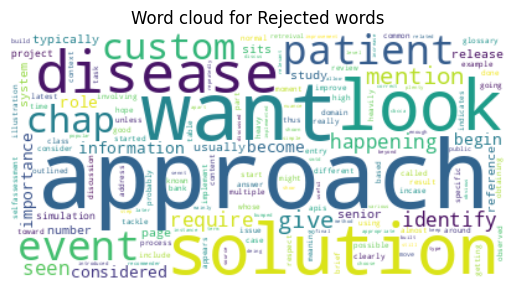

In [13]:
rejected_text=("review selfassessment called answer include case observed class task example disease result normal using whose glossary illustration moment clearly patient event time consider want tackle solution custom chap good mention multiple solution domain process part give hope could would should might incase happening involving mention happening different want unless common require improve approach implement possible specific discussion outlined really like high done based give toward custom start apis seen getting started approach issue address thus going obtaining almost entry latest look around known respect context meaning appears probably indicates hence approach heavily heavy bank table content brief retreival like could look public want build move appropriate step final identify discussed introduced chap choose later discus mainly beyond requires useful cbcca seen recommender like nuance bumped term instance built apart look show improvement shown however correct relevant information enough allow importance repeatedly simple importance popular keep identify type deing still method approach plenty implemented smtd information sennt related solution various level increase obvious role source considered begin abruptly occured several patients disease whenever become typically identified role become became well recognized considered even apparent sits usually image showing sits stand resolve since take leak minute hour need consideration choice event typical begin delayed usually established generally refer pain suspected evaluated important physical nding typically sign produce exhaustive investigation right individual left sitting standing relieved invade used exclude marked contained suggests structure release primary release released htsp induces many damage cell supply cause associate professor fracp frcp medicine francisco california peter goadsby senior scientist massachusetts director hospital belmont shlomo melmed senior vice president dean medical facultyitification search appraoch model system point section study figure chapter index bibliographical bibliography exercise summary references introduction page author reference title number pages number embedded system robotics designing simulation matlab simulation aeromodelling month week industrial training major minor project thesis strobotix chandigarh therefore either other study project with which will their given also over does more nadh although the what none that thorough often occurs note university college lecture ification problem building following present fforamen asbody languagesay languages student")
wordcloud = WordCloud(background_color="white",max_words=5000, contour_width=3).generate(rejected_text)
plt.title("Word cloud for Rejected words")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

**Word cloud visualization for each books**

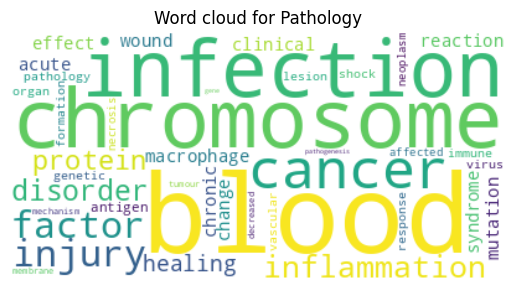

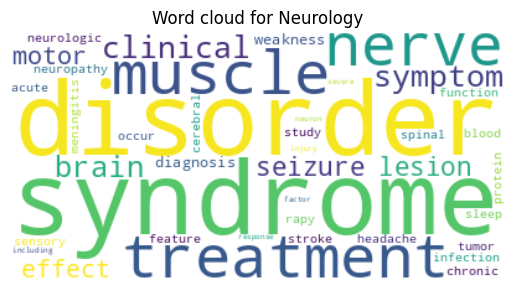

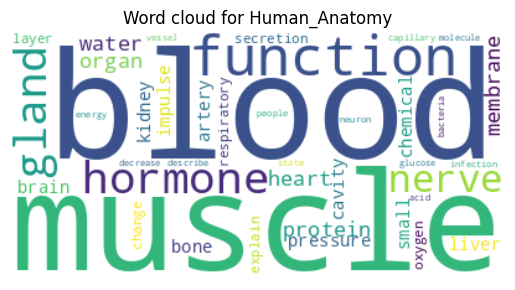

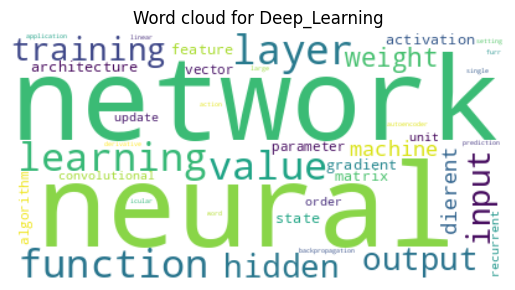

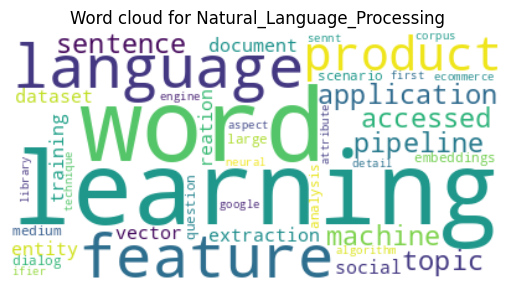

In [14]:
def word_cloud_generation(file_name, file_path):
  df_after_cleansing = pd.read_csv(file_path, names = ['Cleansed_Text'])
  Cleansed_Text_df = ' '.join(df_after_cleansing.Cleansed_Text)
  token_data = word_tokenize(str(Cleansed_Text_df))
  top = Counter(word for word in token_data)
  temp_df_after_cleansing = pd.DataFrame(top.most_common(40))
  temp_df_after_cleansing.columns = ['Common_Words','Count']
  temp_df_after_cleansing.style.background_gradient(cmap = 'Blues')

  wordcloud_text = ','.join(list(temp_df_after_cleansing['Common_Words'].values))
  wordcloud = WordCloud(background_color="white",max_words=5000, contour_width=3).generate(str(wordcloud_text))
  #wordcloud = WordCloud().generate(str(wordcloud_text))
  #wordcloud.to_file("img/wine.png")
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.title("Word cloud for " +file_name)
  plt.axis("off")
  plt.show()
  #wordcloud.to_image()
word_cloud_generation("Pathology", "/home/sdp950/Desktop/nlp_task1/Output_Files/Pathology/Pathology.txt")
word_cloud_generation("Neurology", "/home/sdp950/Desktop/nlp_task1/Output_Files/Neurology/Neurology.txt")
word_cloud_generation("Human_Anatomy", "/home/sdp950/Desktop/nlp_task1/Output_Files/HumanAnatomy/HumanAnatomy.txt")
word_cloud_generation("Deep_Learning", "/home/sdp950/Desktop/nlp_task1/Output_Files/DeepLearning/DeepLearning.txt")
word_cloud_generation("Natural_Language_Processing", "/home/sdp950/Desktop/nlp_task1/Output_Files/NaturalLanguageProcessing/NaturalLanguageProcessing.txt")

In [15]:
def zip_folder(folder_path, output_zip_path):
    with zipfile.ZipFile(output_zip_path, "w") as zip_file:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                zip_file.write(file_path)

if __name__ == "__main__":
    folder_path = "/home/sdp950/Desktop/nlp_task1/Books_Cleansed"
    output_zip_path = "/home/sdp950/Desktop/nlp_task1/Books_Cleansed.zip"

    zip_folder(folder_path, output_zip_path)

In [16]:
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices)>0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

2024-04-14 16:13:51.447489: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# **Implementation in Tensorflow**

## Splitting the data into 60% train data and 30% test data and 10% validation set

In [17]:
test_precentage = 0.4
validation_precentage = 0.1
data = load_files(r"/home/sdp950/Desktop/nlp_task1/Books_Cleansed")
X = data.data
y = data.target

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify = y)

test_example = np.array(X[:round(test_precentage * len(X))])
train_example = np.array(X[round(test_precentage * len(X)):])

test_labels = np.array(y[:round(test_precentage * len(X))])
train_labels = np.array(y[round(test_precentage * len(X)):])

print("Training entries: {}, test entries: {}".format(len(train_example), len(test_example)))

print(train_example)
print("Train Labels is:", Counter(train_labels))
print("Test Labels is:", Counter(test_labels))

Training entries: 1494, test entries: 996
[b'opioid drug abuse dependence metabolite block opiate drawal single dose tolerance mental effect opioids lead everincreasing amount drug sustain desired euphoriant effectsas avoid discomfort drawal combination expected consequence strongly reinforcing dependence endogenous opioid peptide opioid dependence uncertain clinical aspect abuse tied route administration rapidity opiate bolus reaching brain intravenous smoked administration routine efcient route rapidly bolus drug concentration brain bolus rush followed euphoria feeling tranquility sleepiness heroin effect last forestall manifestation drawal dependent person symptom opioid drawal last dose symptom reect activity autonomic nervous lacrimation rhinorrhea yawning sweating appear restless sleep followed weakness chill gooseesh cold turkey nausea vomiting muscle ache involuntary ment kicking habit hyperpnea hyperrmia hypertension occur stage drawal syndrome acute course drawal last seconda

## Implementation1 using NNLM-50/2

In [18]:
model1 = "https://tfhub.dev/google/nnlm-en-dim50/2"

hub_layer1 = hub.KerasLayer(model1, input_shape=[], dtype=tf.string, trainable=True)
hub_layer1(train_example[:3])

<tf.Tensor: shape=(3, 50), dtype=float32, numpy=
array([[ 1.5077262 , -2.7451935 ,  0.099147  , -1.6343758 , -0.35492864,
        -1.2468998 , -0.4786749 ,  1.4087405 , -0.60875773, -0.46378288,
         0.65543914, -0.7586413 ,  1.2948092 , -1.742604  , -1.6865927 ,
        -1.628609  ,  1.9897271 , -1.0047399 ,  0.3720222 ,  0.04087136,
         0.3887924 ,  1.1393496 ,  1.9557921 , -0.83307064, -0.1658757 ,
        -0.8003237 ,  1.306936  ,  2.9158907 ,  0.5404541 , -1.1600661 ,
         0.28926966,  1.5416822 , -0.10626138, -0.54661375,  0.6699145 ,
        -0.8749875 ,  1.5388645 , -0.17981595, -0.940307  , -0.22175354,
         0.46526408, -0.4184508 ,  2.0805569 , -0.16837755,  0.83039856,
         0.41905534,  0.98932123, -0.15384963,  2.2568834 , -0.09048367],
       [ 1.419324  , -0.6655449 ,  0.22452798, -0.4790178 , -0.5921989 ,
        -0.20975469, -0.39193735,  0.14792468, -1.099814  , -0.39508793,
        -0.27457094, -0.09025259,  0.24563026, -0.11114652,  0.15631089,
 

## Creating the model

In [19]:
#Create Model
model1 = tf.keras.Sequential()
model1.add(hub_layer1)
model1.add(tf.keras.layers.Flatten()) #Flattening the layer
#for units in [16, 32, 64, 128]: #4 hidden layers
model1.add(tf.keras.layers.Dense(16, activation='relu'))
model1.add(Dropout(0.5)) #Dropout of 50% in each hidden layer
model1.add(tf.keras.layers.Dense(5, activation = 'softmax')) #Softmax activation for multiclass Classification
optimize = keras.optimizers.Adam(learning_rate=0.01)

## Compiling the model

In [20]:
#Compile model
model1.compile(optimizer=optimize, loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['sparse_categorical_accuracy'])
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 50)                48190600  
                                                                 
 flatten (Flatten)           (None, 50)                0         
                                                                 
 dense (Dense)               (None, 16)                816       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 85        
                                                                 
Total params: 48191501 (183.84 MB)
Trainable params: 48191501 (183.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [21]:
x_val1 = train_example[:round(validation_precentage * len(train_example))]
partial_x_train1 = train_example[round(validation_precentage * len(train_example)):]

y_labels1 = train_labels[:round(validation_precentage * len(train_example))]
partial_y_train_labels1 = train_labels[round(validation_precentage * len(train_example)):]

In [22]:
from keras import callbacks
earlystopping = callbacks.EarlyStopping(monitor="val_loss",
                                        mode="min",
                                        patience=5,
                                        restore_best_weights=True)

In [23]:
start = time.perf_counter()
history1 = model1.fit(partial_x_train1,
                    partial_y_train_labels1,
                    epochs=30,
                    batch_size=512,
                    validation_data=(x_val1, y_labels1),
                    verbose=1,
                    callbacks=[earlystopping]) #A bar depicting the progress of training is displayed

elapsed_time = time.perf_counter() - start
print("Elapsed time for NNLM 50 dimension is %.2f seconds." %elapsed_time)

Epoch 1/30
3/3 [==============================] - 3s 863ms/step - loss: 1.5801 - sparse_categorical_accuracy: 0.3257 - val_loss: 0.9597 - val_sparse_categorical_accuracy: 0.6980
Epoch 2/30
3/3 [==============================] - 2s 652ms/step - loss: 1.0044 - sparse_categorical_accuracy: 0.6134 - val_loss: 0.6753 - val_sparse_categorical_accuracy: 0.8859
Epoch 3/30
3/3 [==============================] - 2s 649ms/step - loss: 0.7791 - sparse_categorical_accuracy: 0.6974 - val_loss: 0.4814 - val_sparse_categorical_accuracy: 0.9060
Epoch 4/30
3/3 [==============================] - 2s 662ms/step - loss: 0.6454 - sparse_categorical_accuracy: 0.7420 - val_loss: 0.3530 - val_sparse_categorical_accuracy: 0.9060
Epoch 5/30
3/3 [==============================] - 2s 654ms/step - loss: 0.5273 - sparse_categorical_accuracy: 0.7859 - val_loss: 0.2551 - val_sparse_categorical_accuracy: 0.9262
Epoch 6/30
3/3 [==============================] - 2s 653ms/step - loss: 0.4779 - sparse_categorical_accuracy: 

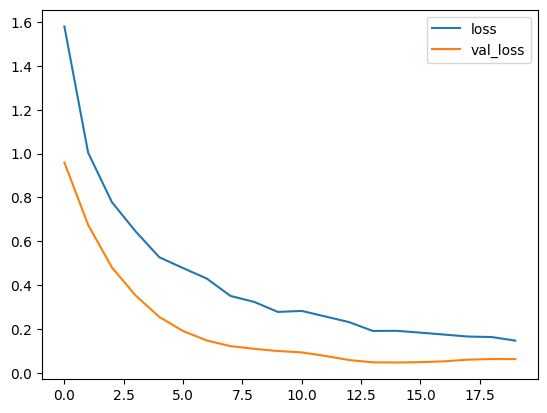

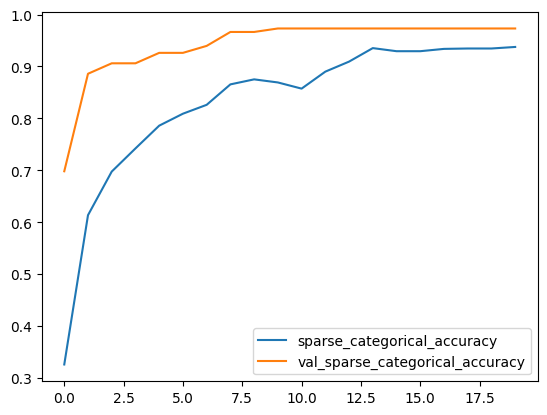

In [24]:
hist_df1 = pd.DataFrame(history1.history)
hist_df1.loc[:, ['loss','val_loss']].plot()
hist_df1.loc[:, ['sparse_categorical_accuracy','val_sparse_categorical_accuracy']].plot()
plt.show()

In [25]:
history_dict1 = history1.history
history_dict1.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

## Evaluating the model

In [26]:
results1 = model1.evaluate(test_example, test_labels)
print(results1)

32/32 [==============================] - 3s 102ms/step - loss: 0.0745 - sparse_categorical_accuracy: 0.9699
[0.0745328888297081, 0.9698795080184937]


## Predicting the model

In [27]:
predictions1 = model1.predict(test_example)
pred_labels1 = predictions1.argmax(axis=1)

32/32 [==============================] - 4s 103ms/step


# Implementation 1 Results

## Training loss vs Validation loss

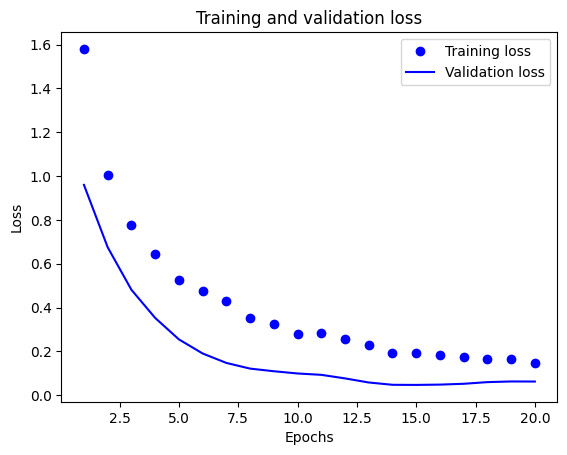

<Figure size 640x480 with 0 Axes>

In [28]:
acc1 = history_dict1['sparse_categorical_accuracy']
val_acc1 = history_dict1['val_sparse_categorical_accuracy']
loss1 = history_dict1['loss']
val_loss1 = history_dict1['val_loss']

epochs1 = range(1, len(acc1) + 1)

plt.plot(epochs1, loss1, 'bo', label='Training loss')
plt.plot(epochs1, val_loss1, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.clf()

## Training Accuracy Vs Validation Accuracy

range(1, 21)


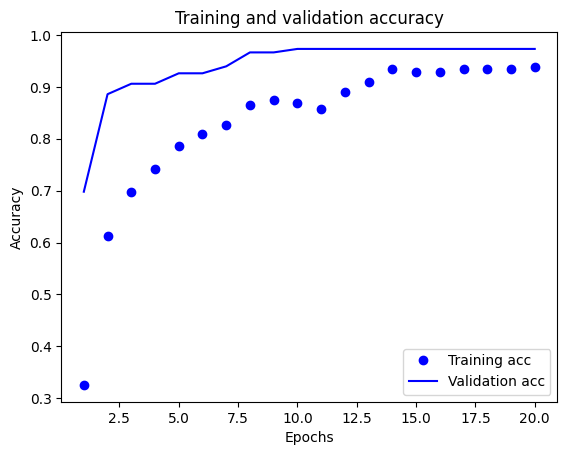

In [29]:
print(epochs1)
plt.plot(epochs1, acc1, 'bo', label='Training acc')
plt.plot(epochs1, val_acc1, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Confusion matrix

[[191   0   2   0   0]
 [  0 225   0   0   0]
 [  0   0 150   0   0]
 [  0   3   0 323   0]
 [  1   3   0  21  77]]


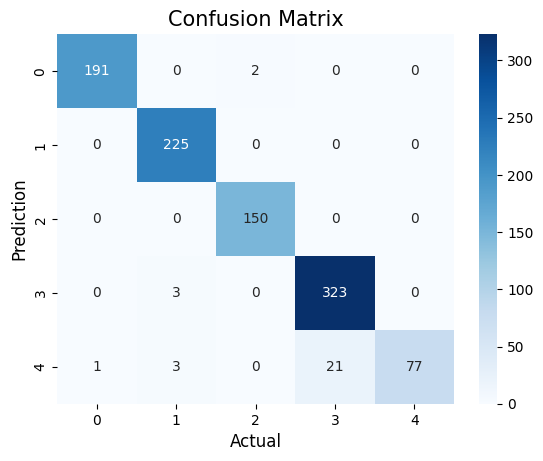

In [30]:
confusionMatrix1 = confusion_matrix(test_labels, pred_labels1)
#acc = metrics.accuracy_score(test_labels, predictions)
#print(classification_report(test_labels, p))

print(confusionMatrix1)
sns.heatmap(confusionMatrix1,
            annot = True,
            fmt="d",
            cmap='Blues'
            )
plt.ylabel('Prediction', fontsize=12)
plt.xlabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

## Metrics calculation

In [31]:
acc1 = metrics.accuracy_score(test_labels, pred_labels1)
print(classification_report(test_labels, pred_labels1))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       193
           1       0.97      1.00      0.99       225
           2       0.99      1.00      0.99       150
           3       0.94      0.99      0.96       326
           4       1.00      0.75      0.86       102

    accuracy                           0.97       996
   macro avg       0.98      0.95      0.96       996
weighted avg       0.97      0.97      0.97       996



In [32]:
recall = recall_score(test_labels, pred_labels1, average='weighted')
print("Recall is:", round(recall*100,2), "%")

Precision_Score = precision_score(test_labels, pred_labels1, average='weighted')
print("Precision Score is:", round(Precision_Score*100,2), "%")

f1_sc = f1_score(test_labels, pred_labels1, average='weighted')
print("F1_Score is:", round(f1_sc*100,2), "%")

Recall is: 96.99 %
Precision Score is: 97.12 %
F1_Score is: 96.85 %


## Implementation2 using NNLM-DIM50-with-Normalization

In [33]:
test_example = np.array(X[:round(test_precentage * len(X))])
train_example = np.array(X[round(test_precentage * len(X)):])

test_labels = np.array(y[:round(test_precentage * len(X))])
train_labels = np.array(y[round(test_precentage * len(X)):])

In [34]:
model2 = "https://tfhub.dev/google/nnlm-en-dim50-with-normalization/2"

hub_layer2 = hub.KerasLayer(model2, input_shape=[], dtype=tf.string, trainable=True)
hub_layer2(train_example[:3])

<tf.Tensor: shape=(3, 50), dtype=float32, numpy=
array([[ 1.5077262 , -2.7451935 ,  0.099147  , -1.6343758 , -0.35492864,
        -1.2468998 , -0.4786749 ,  1.4087405 , -0.60875773, -0.46378288,
         0.65543914, -0.7586413 ,  1.2948092 , -1.742604  , -1.6865927 ,
        -1.628609  ,  1.9897271 , -1.0047399 ,  0.3720222 ,  0.04087136,
         0.3887924 ,  1.1393496 ,  1.9557921 , -0.83307064, -0.1658757 ,
        -0.8003237 ,  1.306936  ,  2.9158907 ,  0.5404541 , -1.1600661 ,
         0.28926966,  1.5416822 , -0.10626138, -0.54661375,  0.6699145 ,
        -0.8749875 ,  1.5388645 , -0.17981595, -0.940307  , -0.22175354,
         0.46526408, -0.4184508 ,  2.0805569 , -0.16837755,  0.83039856,
         0.41905534,  0.98932123, -0.15384963,  2.2568834 , -0.09048367],
       [ 1.419324  , -0.6655449 ,  0.22452798, -0.4790178 , -0.5921989 ,
        -0.20975469, -0.39193735,  0.14792468, -1.099814  , -0.39508793,
        -0.27457094, -0.09025259,  0.24563026, -0.11114652,  0.15631089,
 

In [35]:
#Create Model
model2 = tf.keras.Sequential()
model2.add(hub_layer2)
model2.add(tf.keras.layers.Flatten()) #Flattening the layer
model2.add(tf.keras.layers.Dense(30, activation='relu'))
model2.add(Dropout(0.5)) #Dropout of 50% in each hidden layer
model2.add(tf.keras.layers.Dense(5, activation = 'softmax')) #Softmax activation for multiclass Classification
optimize = keras.optimizers.Adam(learning_rate=0.01)

In [36]:
#Compile model
model2.compile(optimizer=optimize, loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['sparse_categorical_accuracy'])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 50)                48190600  
                                                                 
 flatten_1 (Flatten)         (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 30)                1530      
                                                                 
 dropout_1 (Dropout)         (None, 30)                0         
                                                                 
 dense_3 (Dense)             (None, 5)                 155       
                                                                 
Total params: 48192285 (183.84 MB)
Trainable params: 48192285 (183.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [37]:
x_val2 = train_example[:round(validation_precentage * len(train_example))]
partial_x_train2 = train_example[round(validation_precentage * len(train_example)):]

y_labels2 = train_labels[:round(validation_precentage * len(train_example))]
partial_y_train_labels2 = train_labels[round(validation_precentage * len(train_example)):]

In [38]:
from keras import callbacks
earlystopping = callbacks.EarlyStopping(monitor="val_loss",
                                        mode="min",
                                        patience=5,
                                        restore_best_weights=True)

In [39]:
start = time.perf_counter()
history2 = model2.fit(partial_x_train2,
                    partial_y_train_labels2,
                    epochs=23,
                    batch_size=512,
                    validation_data=(x_val2, y_labels2),
                    verbose=1,
                    callbacks=[earlystopping])

elapsed_time = time.perf_counter() - start
print("Elapsed time for NNLM 50 dimension with normalization is %.2f seconds." %elapsed_time)

Epoch 1/23
3/3 [==============================] - 2s 771ms/step - loss: 1.7507 - sparse_categorical_accuracy: 0.2900 - val_loss: 0.8541 - val_sparse_categorical_accuracy: 0.7114
Epoch 2/23
3/3 [==============================] - 2s 652ms/step - loss: 0.9797 - sparse_categorical_accuracy: 0.6045 - val_loss: 0.5290 - val_sparse_categorical_accuracy: 0.8591
Epoch 3/23
3/3 [==============================] - 2s 644ms/step - loss: 0.6523 - sparse_categorical_accuracy: 0.7643 - val_loss: 0.3354 - val_sparse_categorical_accuracy: 0.9262
Epoch 4/23
3/3 [==============================] - 2s 670ms/step - loss: 0.4266 - sparse_categorical_accuracy: 0.8743 - val_loss: 0.2117 - val_sparse_categorical_accuracy: 0.9329
Epoch 5/23
3/3 [==============================] - 2s 648ms/step - loss: 0.3153 - sparse_categorical_accuracy: 0.8914 - val_loss: 0.1379 - val_sparse_categorical_accuracy: 0.9664
Epoch 6/23
3/3 [==============================] - 2s 653ms/step - loss: 0.2299 - sparse_categorical_accuracy: 

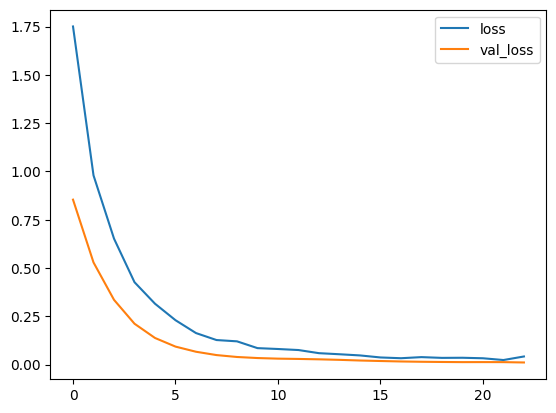

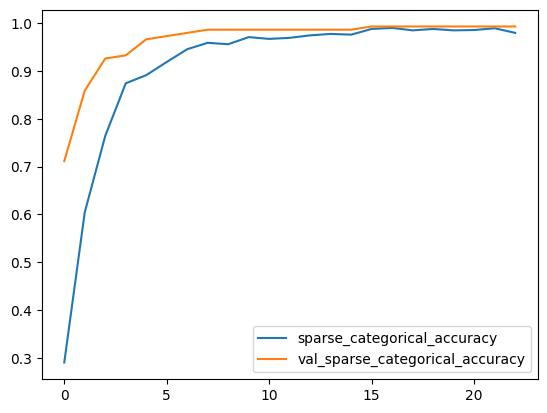

In [40]:
hist_df2 = pd.DataFrame(history2.history)
hist_df2.loc[:, ['loss','val_loss']].plot()
hist_df2.loc[:, ['sparse_categorical_accuracy','val_sparse_categorical_accuracy']].plot()
plt.show()

In [41]:
history_dict2 = history2.history
history_dict2.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

In [42]:
results2 = model2.evaluate(test_example, test_labels)
print(results2)

32/32 [==============================] - 3s 104ms/step - loss: 0.0411 - sparse_categorical_accuracy: 0.9869
[0.04114162176847458, 0.986947774887085]


In [43]:
predictions2 = model2.predict(test_example)
pred_labels2 = predictions2.argmax(axis=1)

32/32 [==============================] - 3s 102ms/step


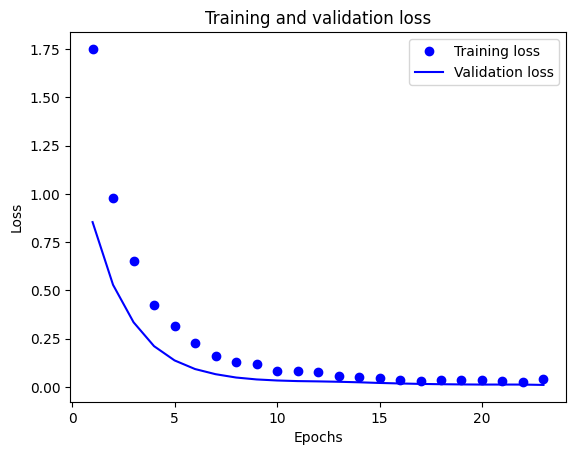

<Figure size 640x480 with 0 Axes>

In [44]:
acc2 = history_dict2['sparse_categorical_accuracy']
val_acc2 = history_dict2['val_sparse_categorical_accuracy']
loss2 = history_dict2['loss']
val_loss2 = history_dict2['val_loss']

epochs2 = range(1, len(acc2) + 1)

plt.plot(epochs2, loss2, 'bo', label='Training loss')
plt.plot(epochs2, val_loss2, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.clf()

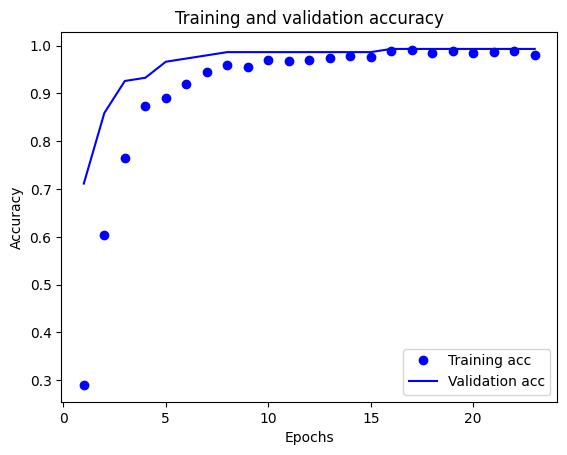

In [45]:
plt.plot(epochs2, acc2, 'bo', label='Training acc')
plt.plot(epochs2, val_acc2, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

[[192   0   1   0   0]
 [  0 225   0   0   0]
 [  0   0 150   0   0]
 [  1   3   0 322   0]
 [  0   3   1   4  94]]


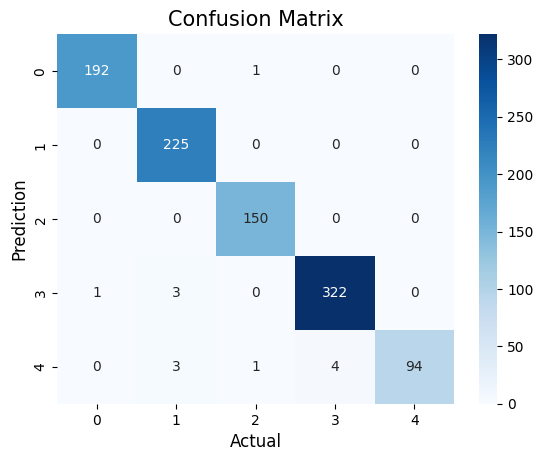

In [46]:
confusionMatrix2 = confusion_matrix(test_labels, pred_labels2)
#acc = metrics.accuracy_score(test_labels, predictions)
#print(classification_report(test_labels, p))

print(confusionMatrix2)
sns.heatmap(confusionMatrix2,
            annot = True,
            fmt="d",
            cmap='Blues'
            )
plt.ylabel('Prediction', fontsize=12)
plt.xlabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

In [47]:
acc = metrics.accuracy_score(test_labels, pred_labels2)
print(classification_report(test_labels, pred_labels2))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       193
           1       0.97      1.00      0.99       225
           2       0.99      1.00      0.99       150
           3       0.99      0.99      0.99       326
           4       1.00      0.92      0.96       102

    accuracy                           0.99       996
   macro avg       0.99      0.98      0.98       996
weighted avg       0.99      0.99      0.99       996



In [48]:
recall = recall_score(test_labels, pred_labels2, average='weighted')
print("Recall is:", round(recall*100) ,"%")

Precision_Score = precision_score(test_labels, pred_labels2, average='weighted')
print("Precision Score is:", round(Precision_Score*100) ,"%")

f1_sc = f1_score(test_labels, pred_labels2, average='weighted')
print("F1_Score is:", round(f1_sc*100) ,"%")

Recall is: 99 %
Precision Score is: 99 %
F1_Score is: 99 %


## Implementation 3 using NNLM-128-with-normalization

In [49]:
test_example = np.array(X[:round(test_precentage * len(X))])
train_example = np.array(X[round(test_precentage * len(X)):])

test_labels = np.array(y[:round(test_precentage * len(X))])
train_labels = np.array(y[round(test_precentage * len(X)):])

In [50]:
model3 = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/2"

hub_layer3 = hub.KerasLayer(model3, input_shape=[], dtype=tf.string, trainable=True)
hub_layer3(train_example[:3])

<tf.Tensor: shape=(3, 128), dtype=float32, numpy=
array([[-0.01816618, -0.20681496, -0.4647684 , -1.141465  , -0.28448752,
         0.00671128,  0.5275455 , -0.00760862,  0.1062403 ,  0.30440134,
         0.6047524 , -0.15402971, -0.66126513,  0.18216789, -1.0843086 ,
        -1.1527969 , -0.3735112 , -0.317511  , -0.6626404 , -0.5959149 ,
         0.737953  ,  0.13516077, -0.11253077, -1.1273876 ,  0.56045836,
         0.6861844 ,  0.90263474,  0.03800775, -0.66493964,  0.17580658,
         0.8273739 , -0.04699069,  0.23543021,  0.74111134,  0.45478466,
         0.3849113 ,  0.2374805 , -0.68432355,  0.6590777 ,  0.14067553,
        -1.1905689 , -0.29847705,  0.39976272, -0.03249314, -0.13071609,
        -0.01068217,  0.00694573,  1.743396  ,  0.74641716,  0.7107049 ,
         0.57597435, -0.6044757 ,  0.5859362 ,  0.17101069,  0.7694083 ,
         0.3769638 ,  0.6821638 ,  0.13492858, -0.33967173,  0.73860955,
         0.37883738, -0.25588736,  0.360781  , -0.3968218 , -0.14651614,
 

In [51]:
#Create Model
model3 = tf.keras.Sequential()
model3.add(hub_layer3)
model3.add(tf.keras.layers.Flatten()) #Flattening the layer
model3.add(tf.keras.layers.Dense(64, activation='relu'))
model3.add(Dropout(0.5)) #Dropout of 50% in each hidden layer
model3.add(tf.keras.layers.Dense(5, activation = 'softmax')) #Softmax activation for multiclass Classification
optimize = keras.optimizers.Adam(learning_rate=0.01)

In [52]:
#Compile model
model3.compile(optimizer=optimize, loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['sparse_categorical_accuracy'])
model3.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_2 (KerasLayer)  (None, 128)               124642688 
                                                                 
 flatten_2 (Flatten)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 5)                 325       
                                                                 
Total params: 124651269 (475.51 MB)
Trainable params: 124651269 (475.51 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [53]:
x_val3 = train_example[:round(validation_precentage * len(train_example))]
partial_x_train3 = train_example[round(validation_precentage * len(train_example)):]

y_labels3 = train_labels[:round(validation_precentage * len(train_example))]
partial_y_train_labels3 = train_labels[round(validation_precentage * len(train_example)):]

In [54]:
from keras import callbacks
earlystopping = callbacks.EarlyStopping(monitor="val_loss",
                                        mode="min",
                                        patience=5,
                                        restore_best_weights=True)

In [55]:
import time
start = time.perf_counter()
history3 = model3.fit(partial_x_train3,
                    partial_y_train_labels3,
                    epochs=9,
                    batch_size=512,
                    validation_data=(x_val3, y_labels3),
                    verbose=1,
                    callbacks=[earlystopping])

elapsed_time = time.perf_counter() - start
print("Elapsed time for NNLM 128 dimension with normalization is %.2f seconds." %elapsed_time)

Epoch 1/9
3/3 [==============================] - 5s 2s/step - loss: 1.3072 - sparse_categorical_accuracy: 0.4989 - val_loss: 0.4427 - val_sparse_categorical_accuracy: 0.8993
Epoch 2/9
3/3 [==============================] - 5s 2s/step - loss: 0.4803 - sparse_categorical_accuracy: 0.8625 - val_loss: 0.1827 - val_sparse_categorical_accuracy: 0.9329
Epoch 3/9
3/3 [==============================] - 5s 2s/step - loss: 0.2042 - sparse_categorical_accuracy: 0.9145 - val_loss: 0.1017 - val_sparse_categorical_accuracy: 0.9597
Epoch 4/9
3/3 [==============================] - 5s 2s/step - loss: 0.0902 - sparse_categorical_accuracy: 0.9770 - val_loss: 0.0675 - val_sparse_categorical_accuracy: 0.9799
Epoch 5/9
3/3 [==============================] - 5s 2s/step - loss: 0.0420 - sparse_categorical_accuracy: 0.9941 - val_loss: 0.0460 - val_sparse_categorical_accuracy: 0.9866
Epoch 6/9
3/3 [==============================] - 5s 2s/step - loss: 0.0210 - sparse_categorical_accuracy: 0.9970 - val_loss: 0.036

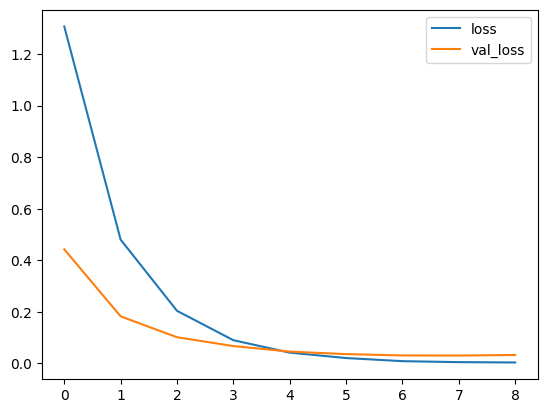

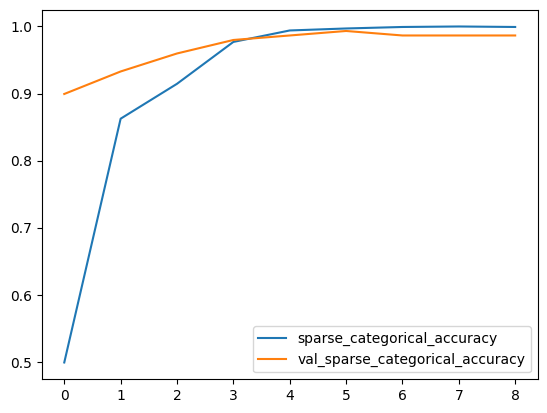

In [56]:
hist_df3 = pd.DataFrame(history3.history)
hist_df3.loc[:, ['loss','val_loss']].plot()
hist_df3.loc[:, ['sparse_categorical_accuracy','val_sparse_categorical_accuracy']].plot()
plt.show()

In [57]:
history_dict3 = history3.history
history_dict3.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

In [58]:
results3 = model3.evaluate(test_example, test_labels)
print(results3)

32/32 [==============================] - 8s 263ms/step - loss: 0.0371 - sparse_categorical_accuracy: 0.9869
[0.037085648626089096, 0.986947774887085]


In [59]:
predictions3 = model3.predict(test_example)
pred_labels3 = predictions3.argmax(axis=1)

32/32 [==============================] - 8s 261ms/step


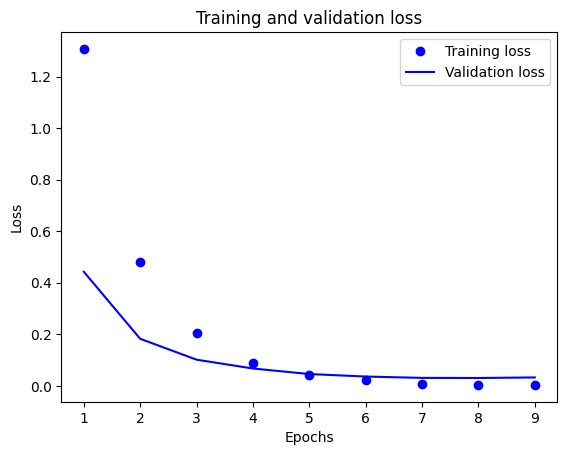

<Figure size 640x480 with 0 Axes>

In [60]:
acc3 = history_dict3['sparse_categorical_accuracy']
val_acc3 = history_dict3['val_sparse_categorical_accuracy']
loss3 = history_dict3['loss']
val_loss3 = history_dict3['val_loss']

epochs3 = range(1, len(acc3) + 1)

plt.plot(epochs3, loss3, 'bo', label='Training loss')
plt.plot(epochs3, val_loss3, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.clf()

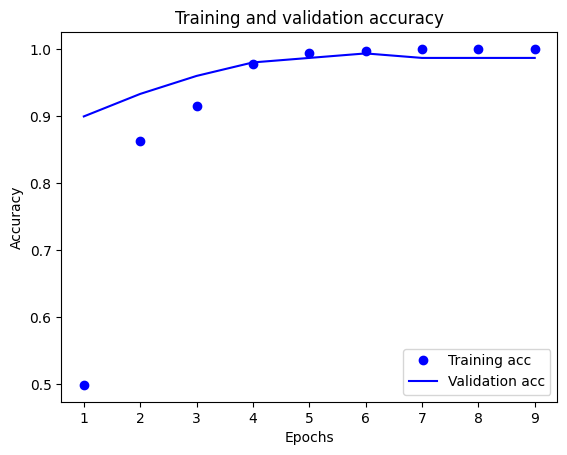

In [61]:
plt.plot(epochs3, acc3, 'bo', label='Training acc')
plt.plot(epochs3, val_acc3, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

[[193   0   0   0   0]
 [  0 224   0   1   0]
 [  2   0 148   0   0]
 [  0   3   0 322   1]
 [  0   3   0   3  96]]


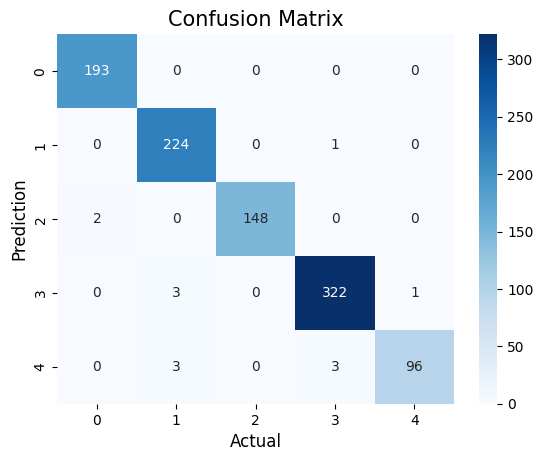

In [62]:
confusionMatrix3 = confusion_matrix(test_labels, pred_labels3)
#acc = metrics.accuracy_score(test_labels, predictions)
#print(classification_report(test_labels, p))

print(confusionMatrix3)
sns.heatmap(confusionMatrix3,
            annot = True,
            fmt="d",
            cmap='Blues'
            )
plt.ylabel('Prediction', fontsize=12)
plt.xlabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

In [63]:
acc3 = metrics.accuracy_score(test_labels, pred_labels3)
print(classification_report(test_labels, pred_labels3))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       193
           1       0.97      1.00      0.98       225
           2       1.00      0.99      0.99       150
           3       0.99      0.99      0.99       326
           4       0.99      0.94      0.96       102

    accuracy                           0.99       996
   macro avg       0.99      0.98      0.99       996
weighted avg       0.99      0.99      0.99       996



In [64]:
recall = recall_score(test_labels, pred_labels3, average='weighted')
print("Recall is:", round(recall*100) , "%")

Precision_Score = precision_score(test_labels, pred_labels3, average='weighted')
print("Precision Score is:", round(Precision_Score*100) , "%")

f1_sc = f1_score(test_labels, pred_labels3, average='weighted')
print("F1_Score is:", round(f1_sc*100) , "%")

Recall is: 99 %
Precision Score is: 99 %
F1_Score is: 99 %


## Implementation 4 using Universal Sentence Embedding Technique(USE)

In [65]:
test_example = np.array(X[:round(test_precentage * len(X))])
train_example = np.array(X[round(test_precentage * len(X)):])

test_labels = np.array(y[:round(test_precentage * len(X))])
train_labels = np.array(y[round(test_precentage * len(X)):])

In [66]:
model4 = "https://tfhub.dev/google/universal-sentence-encoder/4"

hub_layer4 = hub.KerasLayer(model4, input_shape=[], dtype=tf.string, trainable=True)
hub_layer4(train_example[:3])

<tf.Tensor: shape=(3, 512), dtype=float32, numpy=
array([[-0.04553485, -0.04553407,  0.04553818, ..., -0.04553828,
        -0.04553828, -0.04553095],
       [ 0.03850408, -0.05183485, -0.05171411, ...,  0.05183898,
        -0.05183686, -0.05183399],
       [ 0.04611592, -0.04603096,  0.04612339, ..., -0.04612339,
        -0.04612339, -0.03764345]], dtype=float32)>

In [67]:
#Create Model
model4 = tf.keras.Sequential()
model4.add(hub_layer4)
model4.add(tf.keras.layers.Flatten()) #Flattening the layer
model4.add(tf.keras.layers.Dense(16, activation='relu'))
model4.add(Dropout(0.4)) #Dropout of 40% in each hidden layer
model4.add(tf.keras.layers.Dense(5, activation = 'softmax')) #Softmax activation for multiclass Classification
optimize = keras.optimizers.Adam(learning_rate=0.01)

In [68]:
x_val4 = train_example[:round(validation_precentage * len(train_example))]
partial_x_train4 = train_example[round(validation_precentage * len(train_example)):]

y_labels4 = train_labels[:round(validation_precentage * len(train_example))]
partial_y_train_labels4 = train_labels[round(validation_precentage * len(train_example)):]

In [69]:
from keras import callbacks
earlystopping = callbacks.EarlyStopping(monitor="val_loss",
                                        mode="min",
                                        patience=5,
                                        restore_best_weights=True)

In [70]:
#Compile model
model4.compile(optimizer=optimize, loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['sparse_categorical_accuracy'])
model4.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 512)               256797824 
                                                                 
 flatten_3 (Flatten)         (None, 512)               0         
                                                                 
 dense_6 (Dense)             (None, 16)                8208      
                                                                 
 dropout_3 (Dropout)         (None, 16)                0         
                                                                 
 dense_7 (Dense)             (None, 5)                 85        
                                                                 
Total params: 256806117 (979.64 MB)
Trainable params: 256806117 (979.64 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [71]:
start = time.perf_counter()
history4 = model4.fit(partial_x_train4,
                    partial_y_train_labels4,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val4, y_labels4),
                    verbose=1,
                    callbacks=[earlystopping])

elapsed_time = time.perf_counter() - start
print("Elapsed time for Universal Sentence Encoder 4 Embedding Space is %.2f seconds." %elapsed_time)

Epoch 1/20
3/3 [==============================] - 25s 7s/step - loss: 1.5251 - sparse_categorical_accuracy: 0.3123 - val_loss: 1.3033 - val_sparse_categorical_accuracy: 0.5034
Epoch 2/20
3/3 [==============================] - 8s 3s/step - loss: 1.2578 - sparse_categorical_accuracy: 0.4892 - val_loss: 0.9996 - val_sparse_categorical_accuracy: 0.5772
Epoch 3/20
3/3 [==============================] - 8s 3s/step - loss: 0.9809 - sparse_categorical_accuracy: 0.6134 - val_loss: 0.7155 - val_sparse_categorical_accuracy: 0.8859
Epoch 4/20
3/3 [==============================] - 8s 3s/step - loss: 0.7266 - sparse_categorical_accuracy: 0.7985 - val_loss: 0.5042 - val_sparse_categorical_accuracy: 0.9195
Epoch 5/20
3/3 [==============================] - 8s 3s/step - loss: 0.5267 - sparse_categorical_accuracy: 0.8751 - val_loss: 0.3624 - val_sparse_categorical_accuracy: 0.9396
Epoch 6/20
3/3 [==============================] - 8s 3s/step - loss: 0.3937 - sparse_categorical_accuracy: 0.8959 - val_loss

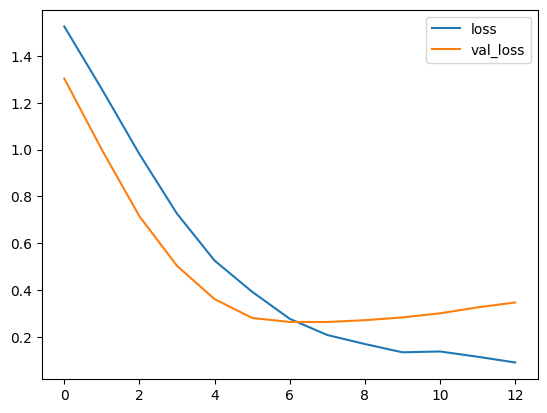

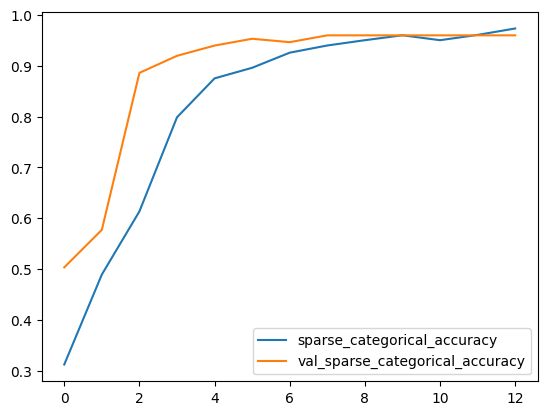

In [72]:
hist_df4 = pd.DataFrame(history4.history)
hist_df4.loc[:, ['loss','val_loss']].plot()
hist_df4.loc[:, ['sparse_categorical_accuracy','val_sparse_categorical_accuracy']].plot()
plt.show()

In [73]:
history_dict4 = history4.history
history_dict4.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

In [74]:
results4 = model4.evaluate(test_example, test_labels)
print(results4)

32/32 [==============================] - 1s 18ms/step - loss: 0.3531 - sparse_categorical_accuracy: 0.9217
[0.3530740439891815, 0.9216867685317993]


In [75]:
predictions4 = model4.predict(test_example)
pred_labels4 = predictions4.argmax(axis=1)

32/32 [==============================] - 1s 18ms/step


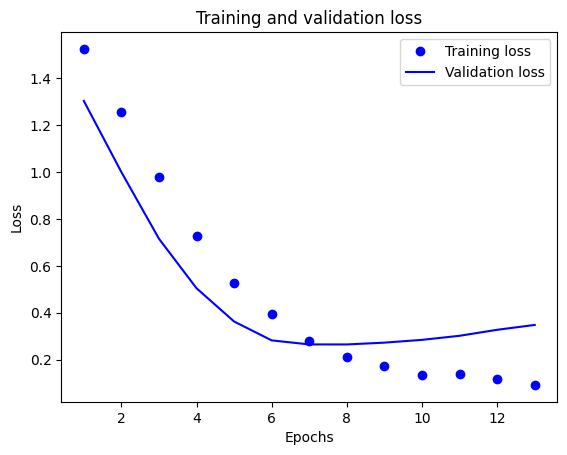

<Figure size 640x480 with 0 Axes>

In [76]:
acc4 = history_dict4['sparse_categorical_accuracy']
val_acc4 = history_dict4['val_sparse_categorical_accuracy']
loss4 = history_dict4['loss']
val_loss4 = history_dict4['val_loss']

epochs4 = range(1, len(acc4) + 1)

plt.plot(epochs4, loss4, 'bo', label='Training loss')
plt.plot(epochs4, val_loss4, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.clf()

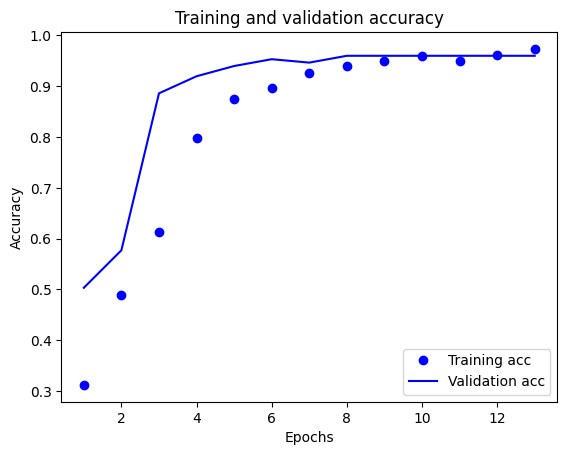

In [77]:
plt.plot(epochs4, acc4, 'bo', label='Training acc')
plt.plot(epochs4, val_acc4, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

[[191   0   2   0   0]
 [  0 225   0   0   0]
 [  8   0 142   0   0]
 [  1  13   0 312   0]
 [  1  52   1   0  48]]


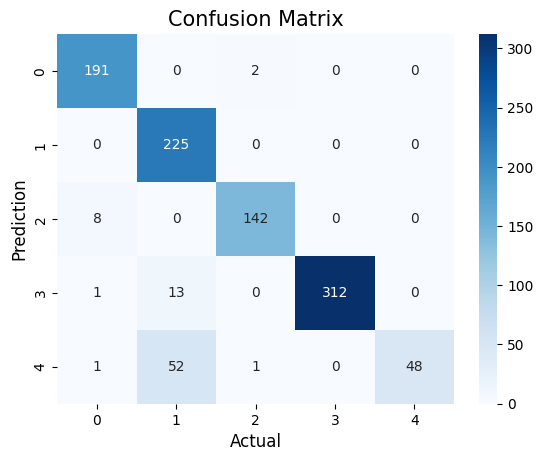

In [78]:
confusionMatrix4 = confusion_matrix(test_labels, pred_labels4)
#acc = metrics.accuracy_score(test_labels, predictions)
#print(classification_report(test_labels, p))

print(confusionMatrix4)
sns.heatmap(confusionMatrix4,
            annot = True,
            fmt="d",
            cmap='Blues'
            )
plt.ylabel('Prediction', fontsize=12)
plt.xlabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

In [79]:
acc4 = metrics.accuracy_score(test_labels, pred_labels4)
print(classification_report(test_labels, pred_labels4))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       193
           1       0.78      1.00      0.87       225
           2       0.98      0.95      0.96       150
           3       1.00      0.96      0.98       326
           4       1.00      0.47      0.64       102

    accuracy                           0.92       996
   macro avg       0.94      0.87      0.88       996
weighted avg       0.94      0.92      0.92       996



In [80]:
recall = recall_score(test_labels, pred_labels4, average='weighted')
print("Recall is:", round(recall*100) , "%")

Precision_Score = precision_score(test_labels, pred_labels4, average='weighted')
print("Precision Score is:", round(Precision_Score*100) , "%")

f1_sc = f1_score(test_labels, pred_labels4, average='weighted')
print("F1_Score is:", round(f1_sc*100) , "%")

Recall is: 92 %
Precision Score is: 94 %
F1_Score is: 92 %


## Implementation 5 - Using word embeddings Text Vectorization

In [81]:
batch_size = 1024
seed = 125
train_ds = tf.keras.utils.text_dataset_from_directory(
    '/home/sdp950/Desktop/nlp_task1/Books_Cleansed', batch_size=batch_size, validation_split = 0.4,
    subset='training',seed = seed
)

val_ds = tf.keras.utils.text_dataset_from_directory(
    '/home/sdp950/Desktop/nlp_task1/Books_Cleansed', batch_size=batch_size, validation_split = 0.4,
    subset='validation',seed = seed
)

Found 2490 files belonging to 5 classes.
Using 1494 files for training.
Found 2490 files belonging to 5 classes.
Using 996 files for validation.


In [82]:
for text_batch, label_batch in train_ds.take(10):
  for i in range(10):
    print(label_batch[i].numpy(), text_batch.numpy()[i])

3 b'clinical manifestation neurologic central mechanism spinal cord axon afferent nociceptors enter spinal cord dorsal root inate dorsal horn spinal gray matter inal afferent axon contact spinal transmit brain site involved perception afferent activated noxious stimulus neurotransmitter inal excite spinal cord neuron major neurotransmitter glutamate rapidly excites dorsal horn neuron afferent nociceptor inal peptide including substance calcitonin gene peptide slower longerlasting excitation dorsal horn neuron axon afferent contact spinal neuron spinal neuron receives convergent input afferent convergence sensory input single spinal transmission neuron great underlies phenomenon spinal neuron receive input viscera deep musculoskeletal receive input skin convergence pattern deined spinal segment dorsal root ganglion afferent innervation afferent central diaphragm derived third fourth cervical dorsal root ganglion afferent body ganglion skin lower neck sensory input skin central diaphragm

In [83]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [84]:
vocab_size = 90000
sequence_length = 100

vectorize_layer = TextVectorization(
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length)

In [85]:
text_ds = train_ds.map(lambda x, y: x)
vectorize_layer.adapt(text_ds)

In [86]:
embedding_dim=50

model5 = Sequential([
  vectorize_layer,
  Embedding(vocab_size, embedding_dim, name="embedding"),
  GlobalAveragePooling1D(),
  Dense(40, activation = 'relu'),
  Dense(5, activation = 'softmax')
])

In [87]:
model5.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [88]:
start = time.perf_counter()
history5 = model5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60)

elapsed_time = time.perf_counter() - start
print("Elapsed time for word embedding technique using vectorization is %.3f seconds." %elapsed_time)

Epoch 1/60
2/2 [==============================] - 1s 373ms/step - loss: 1.6092 - accuracy: 0.2396 - val_loss: 1.6051 - val_accuracy: 0.5120
Epoch 2/60
2/2 [==============================] - 0s 72ms/step - loss: 1.6040 - accuracy: 0.5201 - val_loss: 1.5999 - val_accuracy: 0.5803
Epoch 3/60
2/2 [==============================] - 0s 74ms/step - loss: 1.5979 - accuracy: 0.6098 - val_loss: 1.5935 - val_accuracy: 0.6386
Epoch 4/60
2/2 [==============================] - 0s 76ms/step - loss: 1.5905 - accuracy: 0.6834 - val_loss: 1.5862 - val_accuracy: 0.7118
Epoch 5/60
2/2 [==============================] - 0s 71ms/step - loss: 1.5821 - accuracy: 0.7490 - val_loss: 1.5782 - val_accuracy: 0.7540
Epoch 6/60
2/2 [==============================] - 0s 70ms/step - loss: 1.5729 - accuracy: 0.7905 - val_loss: 1.5695 - val_accuracy: 0.7811
Epoch 7/60
2/2 [==============================] - 0s 71ms/step - loss: 1.5630 - accuracy: 0.8193 - val_loss: 1.5602 - val_accuracy: 0.8062
Epoch 8/60
2/2 [==========

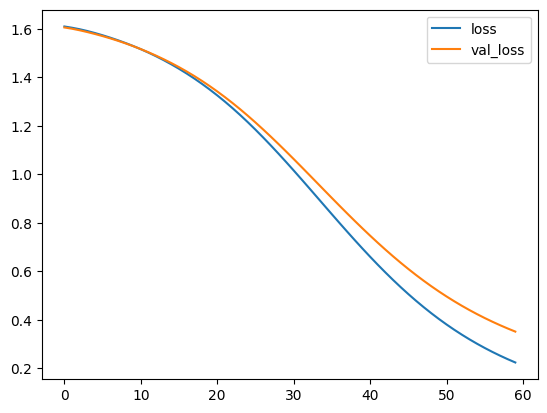

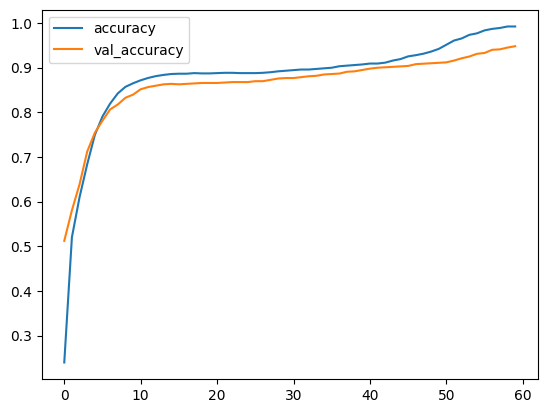

In [89]:
hist_df5 = pd.DataFrame(history5.history)
hist_df5.loc[:, ['loss','val_loss']].plot()
hist_df5.loc[:, ['accuracy','val_accuracy']].plot()
plt.show()

In [90]:
history_dict5 = history5.history
history_dict5.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [91]:
results5 = model5.evaluate(test_example, test_labels)
print(results5)

32/32 [==============================] - 0s 2ms/step - loss: 0.2713 - accuracy: 0.9729
[0.27134159207344055, 0.9728915691375732]


In [92]:
predictions5 = model5.predict(test_example)
pred_labels5 = predictions5.argmax(axis=1)

32/32 [==============================] - 0s 2ms/step


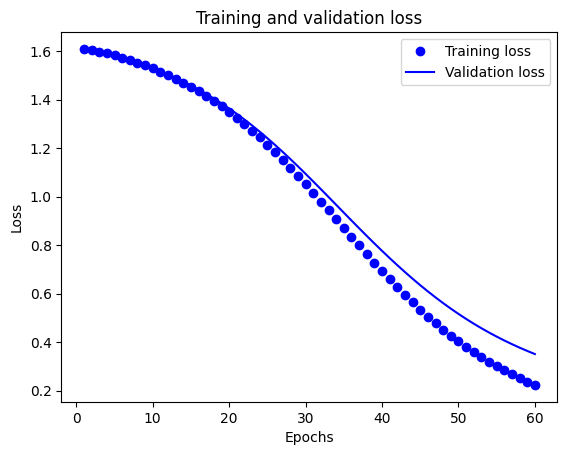

<Figure size 640x480 with 0 Axes>

In [93]:
acc5 = history_dict5['accuracy']
val_acc5 = history_dict5['val_accuracy']
loss5 = history_dict5['loss']
val_loss5 = history_dict5['val_loss']

epochs5 = range(1, len(acc5) + 1)

plt.plot(epochs5, loss5, 'bo', label='Training loss')
plt.plot(epochs5, val_loss5, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.clf()

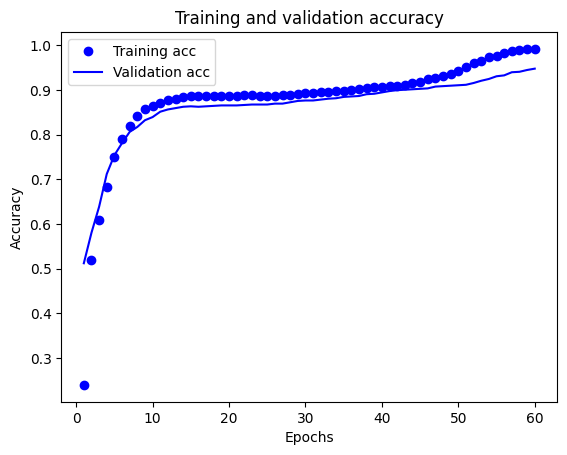

In [94]:
plt.plot(epochs5, acc5, 'bo', label='Training acc')
plt.plot(epochs5, val_acc5, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

[[193   0   0   0   0]
 [  0 223   1   1   0]
 [  1   0 149   0   0]
 [  0   0   0 326   0]
 [  0   3   2  19  78]]


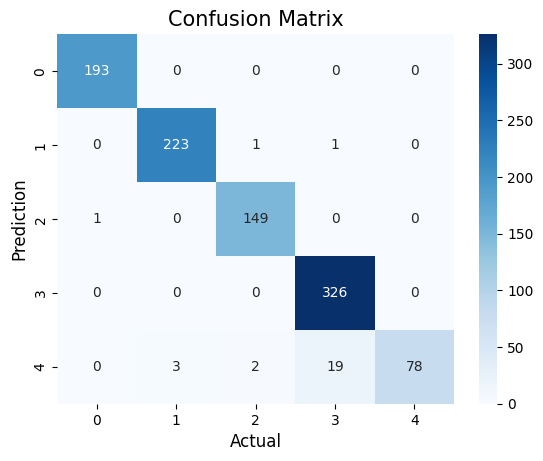

In [95]:
confusionMatrix5 = confusion_matrix(test_labels, pred_labels5)
#acc = metrics.accuracy_score(test_labels, predictions)
#print(classification_report(test_labels, p))

print(confusionMatrix5)
sns.heatmap(confusionMatrix5,
            annot = True,
            fmt="d",
            cmap='Blues'
            )
plt.ylabel('Prediction', fontsize=12)
plt.xlabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

In [96]:
acc5 = metrics.accuracy_score(test_labels, pred_labels5)
print(classification_report(test_labels, pred_labels5))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       193
           1       0.99      0.99      0.99       225
           2       0.98      0.99      0.99       150
           3       0.94      1.00      0.97       326
           4       1.00      0.76      0.87       102

    accuracy                           0.97       996
   macro avg       0.98      0.95      0.96       996
weighted avg       0.97      0.97      0.97       996



In [97]:
recall = recall_score(test_labels, pred_labels5, average='weighted')
print("Recall is:", round(recall*100) , "%")

Precision_Score = precision_score(test_labels, pred_labels5, average='weighted')
print("Precision Score is:", round(Precision_Score*100) , "%")

f1_sc = f1_score(test_labels, pred_labels5, average='weighted')
print("F1_Score is:", round(f1_sc*100) , "%")

Recall is: 97 %
Precision Score is: 97 %
F1_Score is: 97 %


# Conclusion

**Model 1: NNLM dimension 50**

Activated the model with relu and softmax, 16 and 5 weights. Optimizer 'Adam' and Loss function is SparseCategoricalentropy.
Achieved an accuracy of 93.75% and loss: 0.14 at epoch(Number of runs: 20)

**Model 2: NNLM dimension 50 with normalization**

Activated the model with relu and softmax, 16 and 5 weights. Optimizer 'Adam' and Loss function is SparseCategoricalentropy.
Achieved an accuracy of 97.99% and loss: 0.04 at epoch(Number of runs: 23)

**Model 3: NNLM dimension 128 with normalization**

Activated the model with relu and softmax, 16 and 5 weights. Optimizer 'Adam' and Loss function is SparseCategoricalentropy.
Achieved an accuracy of 99.93% and loss: 0.003 at epoch(Number of runs: 9)

**Model 4: Universal Sentence Embedding (USE)**

Activated the model with relu and softmax, 16 and 5 weights. Optimizer 'Adam' and Loss function is SparseCategoricalentropy.
Achieved an accuracy of 97.32% and loss: 0.09 at epoch(Number of runs: 13)

**Model 5: Word Embedding**

Activated the model with relu and softmax, 16 and 5 weights. Optimizer 'Adam' and Loss function is SparseCategoricalentropy.
Achieved an accuracy of 99.2% and loss: 0.23 at epoch(Number of runs: 60)

## Summary

Comparing all the above models, **NNLM dimension 128** with Normalization produces a good accuracy of 99.3% for Multi class Engineering and Medical stream books classification.